# Task 3: Event Detection Using Vision-Language Models

This notebook performs VLM-based event detection for the Group 3 TVSUM videos:
- TVSUM 9
- TVSUM 10
- TVSUM 11
- TVSUM 12

This notebook completes Task 3 of the assignment:
1. It samples video frames.
2. It runs Qwen2.5-VL for event-only detection.
3. It runs Qwen2.5-VL for event + timestamp detection.
4. It parses VLM outputs into structured CSV files.
5. It parses manual annotations.
6. It compares VLM events against manual annotations using sentence embedding similarity.
7. It evaluates prompt strategies: zero-shot, few-shot, and reasoning-guided prompting.
8. It performs failure analysis by listing missed manual events and grouping them by subjectivity.

Expected folder structure:

```text
Comp Vision/
    vlm_event_detection_group3.ipynb
    videos/
        video_9.mp4
        video_10.mp4
        video_11.mp4
        video_12.mp4
```

In [5]:
#imports
import sys
import re
import importlib
import cv2
import torch
import torchvision
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration
from qwen_vl_utils import process_vision_info

from cv_utils import *

In [6]:
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


CUDA available: True
GPU: NVIDIA GeForce RTX 4070 Laptop GPU


In [7]:
GROUP_ID = "Group3"
DATASET_NAME = "TVSUM"

VIDEO_DIR = Path("videos")

OUTPUT_DIR = output_dir("outputs_vlm_event_detection")

VIDEOS = {
    "TVSUM_9": VIDEO_DIR / "video_9.mp4",
    "TVSUM_10": VIDEO_DIR / "video_10.mp4",
    "TVSUM_11": VIDEO_DIR / "video_11.mp4",
    "TVSUM_12": VIDEO_DIR / "video_12.mp4",
}

PLOT= True

FRAME_EVERY_N_SECONDS = 2

MAX_FRAMES_FOR_VLM = 20

In [8]:
# Checking Video Paths
for video_name, video_path in VIDEOS.items():
    print(video_name, "->", video_path)

    if video_path.exists():
        print("  Found")
    else:
        print("  NOT FOUND")

TVSUM_9 -> videos\video_9.mp4
  Found
TVSUM_10 -> videos\video_10.mp4
  Found
TVSUM_11 -> videos\video_11.mp4
  Found
TVSUM_12 -> videos\video_12.mp4
  Found


# Frame Sampling

Instead of passing the full video directly to the VLM, we sample frames at regular intervals.

The frames are sampled every 2 seconds and then uniformly reduced to a maximum of 20 frames. This keeps the input small enough for the model while still covering the full video.

In [9]:
def sample_frames_from_video(video_path, output_frame_dir, every_n_seconds=2, max_frames=None):
    """
    Sample frames from a video every N seconds.

    Parameters
    ----------
    video_path:
        Path to the input video.

    output_frame_dir:
        Folder where sampled frames will be saved.

    every_n_seconds:
        Sampling interval in seconds.

    max_frames:
        Maximum number of frames to keep.
        If the video produces more frames, we uniformly select max_frames.

    Returns
    -------
    sampled_frames:
        A list of dictionaries containing timestamp, seconds, and frame path.
    """

    output_frame_dir = output_dir(output_frame_dir)
    video_path = load_vid_pth(video_path)
    
    cap = cv2.VideoCapture(str(video_path))

    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = cap.get(cv2.CAP_PROP_FRAME_COUNT)

    if fps == 0:
        raise ValueError(f"Could not read FPS from video: {video_path}")

    duration_seconds = frame_count / fps

    sampled_frames = []

    timestamps = np.arange(0, duration_seconds, every_n_seconds)

    # If too many frames, select max_frames uniformly across the whole video
    if max_frames is not None and len(timestamps) > max_frames:
        indices = np.linspace(0, len(timestamps) - 1, max_frames).astype(int)
        timestamps = timestamps[indices]

    for t in timestamps:
        frame_index = int(t * fps)
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_index)

        success, frame = cap.read()

        if not success:
            continue

        # OpenCV reads in BGR, but PIL/matplotlib use RGB
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        timestamp = seconds_to_mmss(t)
        frame_filename = f"frame_{timestamp.replace(':', '-')}.jpg"
        frame_path = output_frame_dir / frame_filename

        Image.fromarray(frame_rgb).save(frame_path)

        sampled_frames.append({
            "timestamp": timestamp,
            "seconds": int(t),
            "frame_path": str(frame_path)
        })

    cap.release()

    return sampled_frames

In [10]:
# Test frame sampling on TVSUM 9

video_name = "TVSUM_9"
video_path = VIDEOS[video_name]

frame_dir = OUTPUT_DIR / video_name / "sampled_frames"

sampled_frames = sample_frames_from_video(
    video_path=video_path,
    output_frame_dir=frame_dir,
    every_n_seconds=FRAME_EVERY_N_SECONDS,
    max_frames=MAX_FRAMES_FOR_VLM
)

sampled_frames_df = pd.DataFrame(sampled_frames)
if PLOT:
    display(sampled_frames_df)

,timestamp,seconds,frame_path
0,00:00,0,outputs_vlm_event_detection\TVSUM_9\sampled_fr...
1,00:12,12,outputs_vlm_event_detection\TVSUM_9\sampled_fr...
2,00:24,24,outputs_vlm_event_detection\TVSUM_9\sampled_fr...
3,00:36,36,outputs_vlm_event_detection\TVSUM_9\sampled_fr...
4,00:48,48,outputs_vlm_event_detection\TVSUM_9\sampled_fr...
5,01:00,60,outputs_vlm_event_detection\TVSUM_9\sampled_fr...
6,01:12,72,outputs_vlm_event_detection\TVSUM_9\sampled_fr...
7,01:24,84,outputs_vlm_event_detection\TVSUM_9\sampled_fr...
8,01:36,96,outputs_vlm_event_detection\TVSUM_9\sampled_fr...
9,01:48,108,outputs_vlm_event_detection\TVSUM_9\sampled_fr...


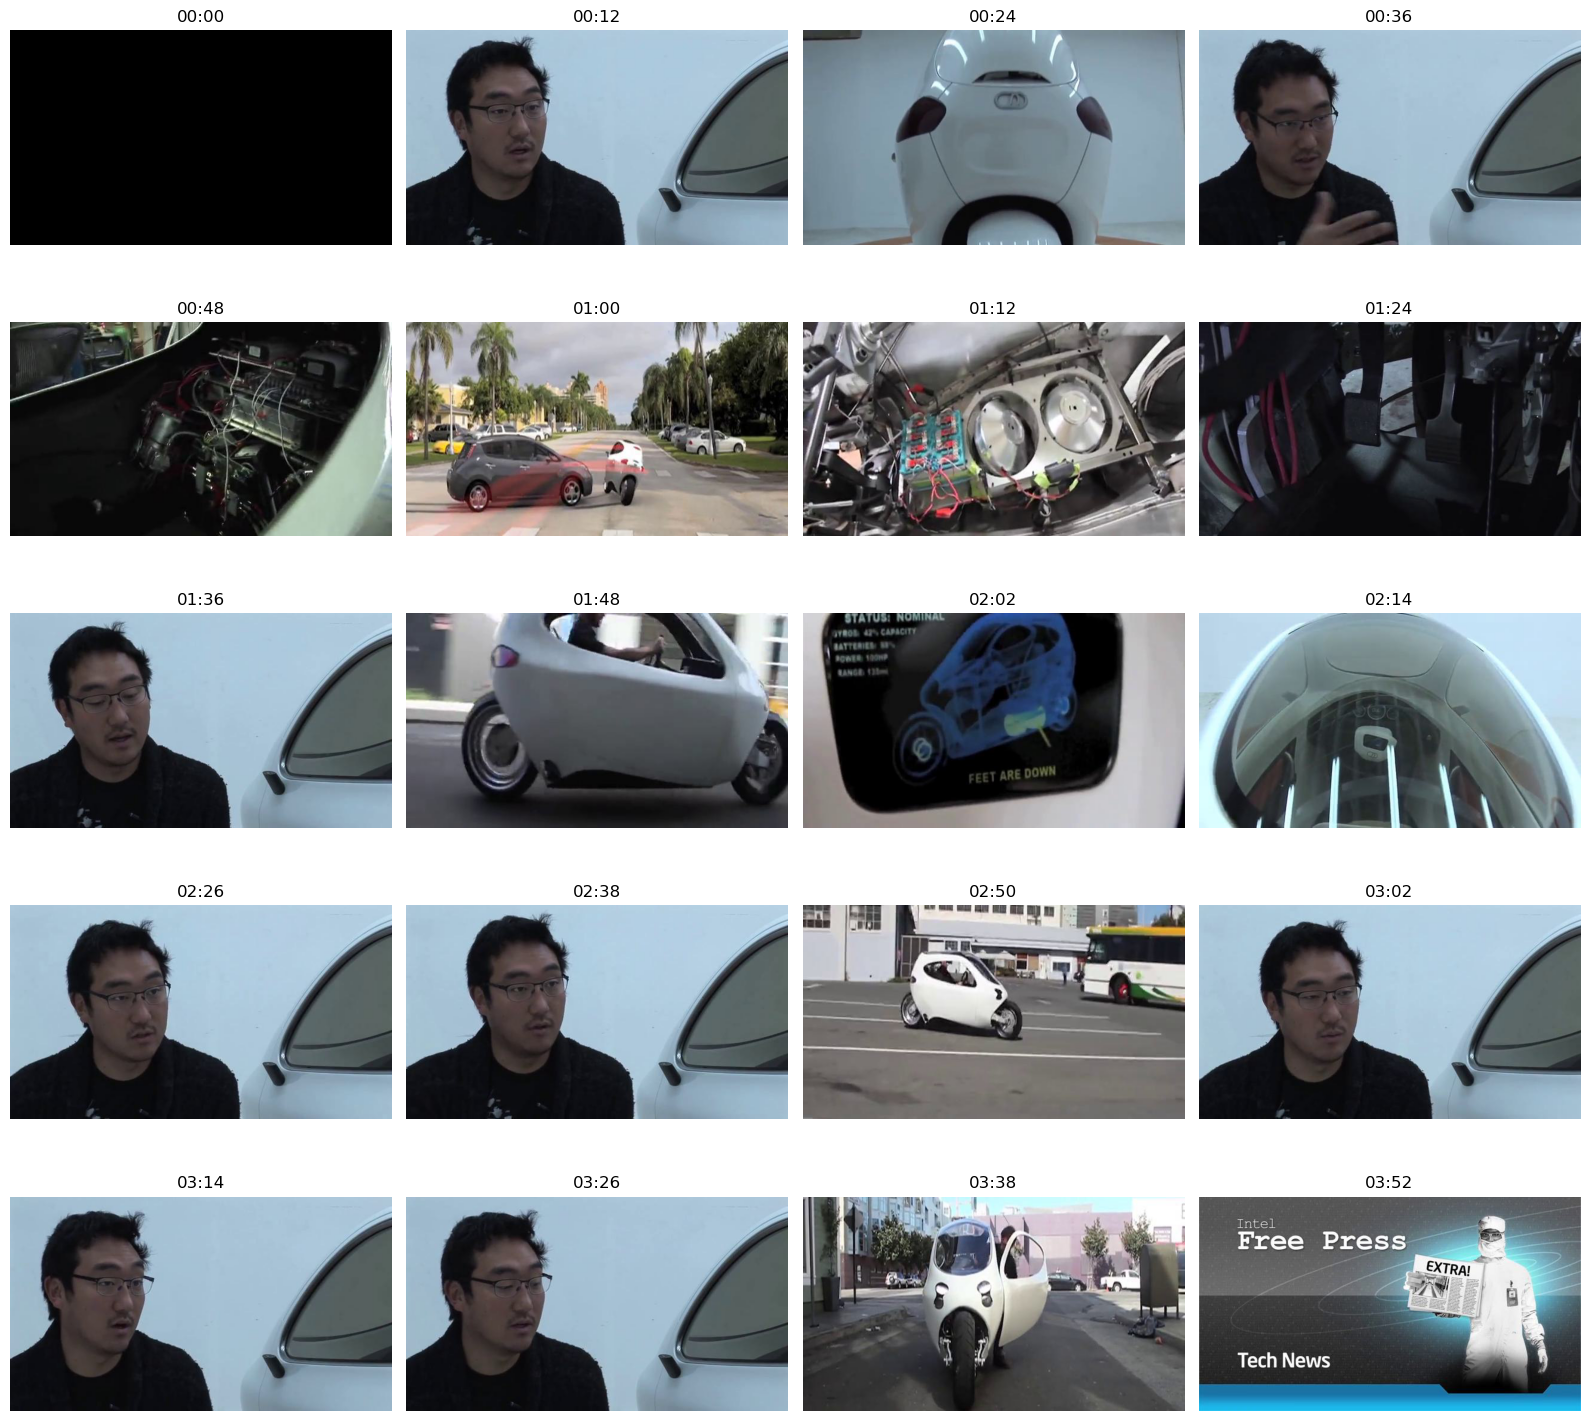

In [11]:
# Visualizing Sampled Frames
def display_sampled_frames(sampled_frames, cols=4):
    """
    Display sampled frames with timestamps.
    """

    n = len(sampled_frames)

    if n == 0:
        print("No frames to display.")
        return

    rows = int(np.ceil(n / cols))

    plt.figure(figsize=(4 * cols, 3 * rows))

    for i, item in enumerate(sampled_frames):
        image = Image.open(item["frame_path"])

        plt.subplot(rows, cols, i + 1)
        plt.imshow(image)
        plt.title(item["timestamp"])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

if PLOT:
    display_sampled_frames(sampled_frames)

In [12]:
EVENT_ONLY_PROMPT = """
You are given sampled frames from a video in chronological order.

Task:
Retrieve all of the salient events of the video.

Rules:
- List only important events needed to understand the video.
- Keep the events in chronological order.
- Use short and clear descriptions.
- Do not describe every frame.
- Do not include timestamps.
- Do not include unimportant visual details.
- Use this exact output format:

Salient event 1: <event description>
Salient event 2: <event description>
Salient event 3: <event description>
"""


EVENT_TIMESTAMP_PROMPT = """
You are given sampled frames from a video in chronological order.
Each frame is labeled with its timestamp.

Task:
Retrieve all of the salient events of the video with temporal localization.

Rules:
- List only important events needed to understand the video.
- Keep events in chronological order.
- Use short and clear descriptions.
- Use precise but realistic timestamps.
- Use MM:SS - MM:SS format.
- Do not describe every frame.
- Do not include unimportant visual details.
- Use this exact output format:

Salient event 1: <event description>, <MM:SS - MM:SS>
Salient event 2: <event description>, <MM:SS - MM:SS>
Salient event 3: <event description>, <MM:SS - MM:SS>
"""

print(EVENT_ONLY_PROMPT)
print(EVENT_TIMESTAMP_PROMPT)


You are given sampled frames from a video in chronological order.

Task:
Retrieve all of the salient events of the video.

Rules:
- List only important events needed to understand the video.
- Keep the events in chronological order.
- Use short and clear descriptions.
- Do not describe every frame.
- Do not include timestamps.
- Do not include unimportant visual details.
- Use this exact output format:

Salient event 1: <event description>
Salient event 2: <event description>
Salient event 3: <event description>


You are given sampled frames from a video in chronological order.
Each frame is labeled with its timestamp.

Task:
Retrieve all of the salient events of the video with temporal localization.

Rules:
- List only important events needed to understand the video.
- Keep events in chronological order.
- Use short and clear descriptions.
- Use precise but realistic timestamps.
- Use MM:SS - MM:SS format.
- Do not describe every frame.
- Do not include unimportant visual details.
-

In [13]:

MODEL_NAME = "Qwen/Qwen2.5-VL-3B-Instruct"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
    device_map="auto" if device == "cuda" else None
)

processor = AutoProcessor.from_pretrained(MODEL_NAME)

if device == "cpu":
    model = model.to(device)

`torch_dtype` is deprecated! Use `dtype` instead!


Using device: cuda


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the cpu.
The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.


In [14]:
def build_vlm_message(sampled_frames, prompt):
    """
    Build a Qwen2.5-VL message containing sampled frames and a text prompt.
    """

    content = []

    for item in sampled_frames:
        content.append({
            "type": "text",
            "text": f"Frame from {item['timestamp']}:"
        })

        content.append({
            "type": "image",
            "image": item["frame_path"]
        })

    content.append({
        "type": "text",
        "text": prompt
    })

    messages = [
        {
            "role": "user",
            "content": content
        }
    ]

    return messages

In [15]:
def run_qwen_vlm(sampled_frames, prompt, max_new_tokens=512):
    """
    Run Qwen2.5-VL on sampled frames using the given prompt.
    """

    messages = build_vlm_message(sampled_frames, prompt)

    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    image_inputs, video_inputs = process_vision_info(messages)

    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt"
    )

    inputs = inputs.to(model.device)

    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens
        )

    generated_ids_trimmed = [
        output_ids[len(input_ids):]
        for input_ids, output_ids in zip(inputs.input_ids, generated_ids)
    ]

    output_text = processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )[0]

    return output_text

In [16]:
# Run event-only prompt on TVSUM 9 for testing 

event_only_output = run_qwen_vlm(
    sampled_frames=sampled_frames,
    prompt=EVENT_ONLY_PROMPT,
    max_new_tokens=512
)

print(event_only_output)

Salient event 1: A man is standing next to a white car, talking.
Salient event 2: The car's hood is open, revealing its internal components.
Salient event 3: The car is driving on a city street, passing by other vehicles.
Salient event 4: The car is shown from different angles, highlighting its design and features.
Salient event 5: The car is parked again, with the man continuing his conversation.


In [17]:
# Run event + timestamp prompt on TVSUM 9 for testing 

event_timestamp_output = run_qwen_vlm(
    sampled_frames=sampled_frames,
    prompt=EVENT_TIMESTAMP_PROMPT,
    max_new_tokens=512
)

print(event_timestamp_output)

Salient event 1: Introduction of the vehicle, 00:00 - 00:12
Salient event 2: Detailed view of the vehicle's front, 00:12 - 00:24
Salient event 3: Man speaking about the vehicle, 00:24 - 00:36
Salient event 4: Interior view of the vehicle, 00:36 - 00:48
Salient event 5: Exterior view of the vehicle on a road, 00:48 - 01:00
Salient event 6: Close-up of the vehicle's engine, 01:00 - 01:12
Salient event 7: Pedal operation demonstration, 01:12 - 01:24
Salient event 8: Man speaking about the vehicle again, 01:24 - 01:36
Salient event 9: Exterior view of the vehicle driving, 01:36 - 01:48
Salient event 10: Display showing battery status, 01:48 - 01:50
Salient event 11: Vehicle driving on a road, 01:50 - 02:02
Salient event 12: Close-up of the vehicle's front, 02:02 - 02:14
Salient event 13: Man speaking about the vehicle again, 02:14 - 02:26
Salient event 14: Exterior view of the vehicle driving, 02:26 - 02:38
Salient event 15: Man speaking about the vehicle again, 02:38 - 02:50
Salient event

In [18]:
# Saving Raw VLM Outputs
def save_text(text, path):
    """
    Save text to a file.
    """

    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    with open(path, "w", encoding="utf-8") as f:
        f.write(text)



video_output_dir = output_dir(OUTPUT_DIR / video_name)


save_text(event_only_output, video_output_dir / "vlm_event_only_raw.txt")
save_text(event_timestamp_output, video_output_dir / "vlm_event_timestamp_raw.txt")

In [19]:
def parse_event_only(vlm_text):
    """
    Parse event-only VLM output.

    Expected format:
    Salient event 1: description
    Salient event 2: description

    Returns:
    DataFrame with columns:
    - event_id
    - event_description
    """

    pattern = r"Salient event\s*(\d+)\s*:\s*(.+)"
    rows = []

    for match in re.finditer(pattern, vlm_text, flags=re.IGNORECASE):
        event_id = int(match.group(1))
        description = match.group(2).strip()

        # Remove accidental timestamp if model included one
        description = re.sub(
            r",?\s*\d{2}:\d{2}\s*-\s*\d{2}:\d{2}",
            "",
            description
        ).strip()

        rows.append({
            "event_id": event_id,
            "event_description": description
        })

    return pd.DataFrame(rows)

In [20]:

def parse_event_with_timestamps(vlm_text):
    """
    Flexible parser for timestamped VLM output.

    Handles:
    Salient event 1: description, 00:00 - 00:20
    Salient event 1: description, MM:00:00 - MM:00:20
    Salient event 1: description, 00:00–00:20
    """

    rows = []

    # Normalize different dash symbols
    vlm_text = normalise_dash(vlm_text)

    pattern = (
        r"Salient event\s*(\d+)\s*:\s*"
        r"(.+),\s*"
        r"(?:MM:)?(\d{1,2}:\d{2})\s*-\s*"
        r"(?:MM:)?(\d{1,2}:\d{2})")

    for match in re.finditer(pattern, vlm_text, flags=re.IGNORECASE):
        event_id = int(match.group(1))
        description = match.group(2).strip()
        start = clean_timestamp(match.group(3))
        end = clean_timestamp(match.group(4))

        rows.append({
            "event_id": event_id,
            "event_description": description,
            "start": start,
            "end": end,
            "start_seconds": mmss_to_seconds_flexible(start),
            "end_seconds": mmss_to_seconds_flexible(end)
        })

    return pd.DataFrame(rows)

In [21]:
parsed_event_only_df = parse_event_only(event_only_output)
parsed_timestamp_df = parse_event_with_timestamps(event_timestamp_output)

print("Event-only parsed output:")
display(parsed_event_only_df)

print("Event + timestamp parsed output:")
display(parsed_timestamp_df)

Event-only parsed output:


,event_id,event_description
0,1,"A man is standing next to a white car, talking."
1,2,"The car's hood is open, revealing its internal..."
2,3,"The car is driving on a city street, passing b..."
3,4,"The car is shown from different angles, highli..."
4,5,"The car is parked again, with the man continui..."


Event + timestamp parsed output:


,event_id,event_description,start,end,start_seconds,end_seconds
0,1,Introduction of the vehicle,00:00,00:12,0,12
1,2,Detailed view of the vehicle's front,00:12,00:24,12,24
2,3,Man speaking about the vehicle,00:24,00:36,24,36
3,4,Interior view of the vehicle,00:36,00:48,36,48
4,5,Exterior view of the vehicle on a road,00:48,01:00,48,60
5,6,Close-up of the vehicle's engine,01:00,01:12,60,72
6,7,Pedal operation demonstration,01:12,01:24,72,84
7,8,Man speaking about the vehicle again,01:24,01:36,84,96
8,9,Exterior view of the vehicle driving,01:36,01:48,96,108
9,10,Display showing battery status,01:48,01:50,108,110


In [22]:
raw_path = OUTPUT_DIR / "TVSUM_9" / "vlm_event_timestamp_raw.txt"

with open(raw_path, "r", encoding="utf-8") as f:
    raw_timestamp_9 = f.read()

print(raw_timestamp_9)

Salient event 1: Introduction of the vehicle, 00:00 - 00:12
Salient event 2: Detailed view of the vehicle's front, 00:12 - 00:24
Salient event 3: Man speaking about the vehicle, 00:24 - 00:36
Salient event 4: Interior view of the vehicle, 00:36 - 00:48
Salient event 5: Exterior view of the vehicle on a road, 00:48 - 01:00
Salient event 6: Close-up of the vehicle's engine, 01:00 - 01:12
Salient event 7: Pedal operation demonstration, 01:12 - 01:24
Salient event 8: Man speaking about the vehicle again, 01:24 - 01:36
Salient event 9: Exterior view of the vehicle driving, 01:36 - 01:48
Salient event 10: Display showing battery status, 01:48 - 01:50
Salient event 11: Vehicle driving on a road, 01:50 - 02:02
Salient event 12: Close-up of the vehicle's front, 02:02 - 02:14
Salient event 13: Man speaking about the vehicle again, 02:14 - 02:26
Salient event 14: Exterior view of the vehicle driving, 02:26 - 02:38
Salient event 15: Man speaking about the vehicle again, 02:38 - 02:50
Salient event

In [23]:
parsed_timestamp_9 = parse_event_with_timestamps(raw_timestamp_9)
display(parsed_timestamp_9)

,event_id,event_description,start,end,start_seconds,end_seconds
0,1,Introduction of the vehicle,00:00,00:12,0,12
1,2,Detailed view of the vehicle's front,00:12,00:24,12,24
2,3,Man speaking about the vehicle,00:24,00:36,24,36
3,4,Interior view of the vehicle,00:36,00:48,36,48
4,5,Exterior view of the vehicle on a road,00:48,01:00,48,60
5,6,Close-up of the vehicle's engine,01:00,01:12,60,72
6,7,Pedal operation demonstration,01:12,01:24,72,84
7,8,Man speaking about the vehicle again,01:24,01:36,84,96
8,9,Exterior view of the vehicle driving,01:36,01:48,96,108
9,10,Display showing battery status,01:48,01:50,108,110


In [24]:
parsed_event_only_df.to_csv(
    video_output_dir / "parsed_event_only.csv",
    index=False
)

parsed_timestamp_df.to_csv(
    video_output_dir / "parsed_event_timestamp.csv",
    index=False
)

In [25]:
def run_and_parse_pipeline(video_name, video_path, output_dir, prompt_name, prompt_text, parser_func):
    """
    Generic pipeline to sample frames, run the VLM, save raw text, and parse the output.
    """
    video_output_dir = output_dir / video_name
    video_output_dir.mkdir(parents=True, exist_ok=True)
    frame_dir = video_output_dir / "sampled_frames"

    sampled_frames = sample_frames_from_video(
        video_path=video_path,
        output_frame_dir=frame_dir,
        every_n_seconds=FRAME_EVERY_N_SECONDS,
        max_frames=MAX_FRAMES_FOR_VLM
    )
    
    sampled_frames_df = pd.DataFrame(sampled_frames)
    sampled_frames_df.to_csv(video_output_dir / "sampled_frames_metadata.csv", index=False)

    vlm_output = run_qwen_vlm(
        sampled_frames=sampled_frames,
        prompt=prompt_text,
        max_new_tokens=512
    )
    
    save_text(vlm_output, video_output_dir / f"vlm_raw_{prompt_name}.txt")

    parsed_df = parser_func(vlm_output)
    
    if parsed_df.empty:
        print(f"\nWARNING: Parser found no events for {prompt_name}.")
        print(vlm_output)

    parsed_df.insert(0, "video_name", video_name)
    parsed_df.insert(1, "prompt_name", prompt_name)
    parsed_df.to_csv(video_output_dir / f"parsed_{prompt_name}.csv", index=False)

    return sampled_frames_df, vlm_output, parsed_df

In [26]:
def process_video_until_parsing(video_name, video_path):
    """
    Runs event-only prompt
    Runs event+timestamp prompt
    """
    print(f"\n==============================")
    print(f"Processing {video_name}")
    print(f"==============================")

    # Event-Only
    print("Event-only prompt")
    sampled_frames_df, event_only_output, parsed_event_only_df = run_and_parse_pipeline(
        video_name=video_name,
        video_path=video_path,
        output_dir=OUTPUT_DIR,
        prompt_name="event_only",
        prompt_text=EVENT_ONLY_PROMPT,
        parser_func=parse_event_only
    )
    
    print("\nEvent-only parsed output:")
    display(parsed_event_only_df)

    # Event + Timestamp Pipeline
    print("Event + timestamp prompt")
    _, event_timestamp_output, parsed_timestamp_df = run_and_parse_pipeline(
        video_name=video_name,
        video_path=video_path,
        output_dir=OUTPUT_DIR,
        prompt_name="event_timestamp",
        prompt_text=EVENT_TIMESTAMP_PROMPT,
        parser_func=parse_event_with_timestamps
    )
    
    print("\nEvent + timestamp parsed output:")
    display(parsed_timestamp_df)

    return {
        "video_name": video_name,
        "sampled_frames": sampled_frames_df,
        "event_only_output": event_only_output,
        "event_timestamp_output": event_timestamp_output,
        "parsed_event_only": parsed_event_only_df,
        "parsed_timestamp": parsed_timestamp_df
    }

In [27]:
all_parsed_results = {}

for video_name, video_path in VIDEOS.items():
    result = process_video_until_parsing(video_name, video_path)
    all_parsed_results[video_name] = result


Processing TVSUM_9
Event-only prompt

Event-only parsed output:


,video_name,prompt_name,event_id,event_description
0,TVSUM_9,event_only,1,"A man is standing next to a white car, talking."
1,TVSUM_9,event_only,2,"The car's hood is open, revealing its internal..."
2,TVSUM_9,event_only,3,"The car is driving on a city street, passing b..."
3,TVSUM_9,event_only,4,"The car is shown from different angles, highli..."
4,TVSUM_9,event_only,5,"The car is parked again, with the man continui..."


Event + timestamp prompt

Event + timestamp parsed output:


,video_name,prompt_name,event_id,event_description,start,end,start_seconds,end_seconds
0,TVSUM_9,event_timestamp,1,Introduction of the vehicle,00:00,00:12,0,12
1,TVSUM_9,event_timestamp,2,Detailed view of the vehicle's front,00:12,00:24,12,24
2,TVSUM_9,event_timestamp,3,Man speaking about the vehicle,00:24,00:36,24,36
3,TVSUM_9,event_timestamp,4,Interior view of the vehicle,00:36,00:48,36,48
4,TVSUM_9,event_timestamp,5,Exterior view of the vehicle on a road,00:48,01:00,48,60
5,TVSUM_9,event_timestamp,6,Close-up of the vehicle's engine,01:00,01:12,60,72
6,TVSUM_9,event_timestamp,7,Pedal operation demonstration,01:12,01:24,72,84
7,TVSUM_9,event_timestamp,8,Man speaking about the vehicle again,01:24,01:36,84,96
8,TVSUM_9,event_timestamp,9,Exterior view of the vehicle driving,01:36,01:48,96,108
9,TVSUM_9,event_timestamp,10,Display showing battery status,01:48,01:50,108,110



Processing TVSUM_10
Event-only prompt

Event-only parsed output:


...

,video_name,prompt_name,event_id,event_description,start,end,start_seconds,end_seconds
0,TVSUM_11,event_timestamp,1,Exterior view of PetJoy,00:00,00:08,0,8
1,TVSUM_11,event_timestamp,2,Grooming session with a golden retriever,00:09,00:16,9,16
2,TVSUM_11,event_timestamp,3,Grooming session with a small dog,00:17,00:24,17,24
3,TVSUM_11,event_timestamp,4,Grooming session with a small dog,00:25,00:32,25,32
4,TVSUM_11,event_timestamp,5,Grooming session with a golden retriever,00:33,00:40,33,40
5,TVSUM_11,event_timestamp,6,Grooming session with a golden retriever,00:41,00:56,41,56
6,TVSUM_11,event_timestamp,7,Grooming session with a small dog,00:57,01:04,57,64
7,TVSUM_11,event_timestamp,8,Grooming session with a small dog,01:05,01:12,65,72
8,TVSUM_11,event_timestamp,9,Grooming session with a small dog,01:13,01:22,73,82
9,TVSUM_11,event_timestamp,10,Grooming session with a small dog,01:23,01:30,83,90



Processing TVSUM_12
Event-only prompt

Event-only parsed output:


,video_name,prompt_name,event_id,event_description
0,TVSUM_12,event_only,1,A person is washing a small white dog in a sink.
1,TVSUM_12,event_only,2,The person applies shampoo to the dog's fur an...
2,TVSUM_12,event_only,3,The person dries the dog with a towel after wa...


Event + timestamp prompt

Event + timestamp parsed output:


,video_name,prompt_name,event_id,event_description,start,end,start_seconds,end_seconds
0,TVSUM_12,event_timestamp,1,Woman washing her hands,00:00,00:05,0,5
1,TVSUM_12,event_timestamp,2,Woman talking to the camera,00:05,00:10,5,10
2,TVSUM_12,event_timestamp,3,Woman brushing her hair,00:10,00:15,10,15
3,TVSUM_12,event_timestamp,4,Woman applying shampoo to the dog,00:15,00:20,15,20
4,TVSUM_12,event_timestamp,5,Woman rinsing the dog,00:20,00:25,20,25
5,TVSUM_12,event_timestamp,6,Woman drying the dog,00:25,00:30,25,30
6,TVSUM_12,event_timestamp,7,Woman talking to the camera,00:30,00:35,30,35
7,TVSUM_12,event_timestamp,8,Woman walking outside,00:35,00:40,35,40
8,TVSUM_12,event_timestamp,9,Woman entering a building,00:40,00:45,40,45
9,TVSUM_12,event_timestamp,10,Woman talking to the camera,00:45,00:50,45,50


In [28]:
all_event_only_dfs = []

for video_name, result in all_parsed_results.items():
    df = result["parsed_event_only"].copy()

    if "video_name" not in df.columns:
        df.insert(0, "video_name", video_name)
    else:
        df["video_name"] = video_name

    all_event_only_dfs.append(df)

all_event_only_df = pd.concat(all_event_only_dfs, ignore_index=True)

display(all_event_only_df)

all_event_only_df.to_csv(
    OUTPUT_DIR / "all_videos_parsed_event_only.csv",
    index=False
)

,video_name,prompt_name,event_id,event_description
0,TVSUM_9,event_only,1,"A man is standing next to a white car, talking."
1,TVSUM_9,event_only,2,"The car's hood is open, revealing its internal..."
2,TVSUM_9,event_only,3,"The car is driving on a city street, passing b..."
3,TVSUM_9,event_only,4,"The car is shown from different angles, highli..."
4,TVSUM_9,event_only,5,"The car is parked again, with the man continui..."
5,TVSUM_10,event_only,1,A news anchor introduces a segment about elect...
6,TVSUM_10,event_only,2,The anchor discusses the establishment of an e...
7,TVSUM_10,event_only,3,"An interview with Yoo Dong-kun, a representati..."
8,TVSUM_10,event_only,4,The video showcases various electric vehicles ...
9,TVSUM_10,event_only,5,A demonstration of a small electric car is sho...


In [29]:
all_timestamp_dfs = []

for video_name, result in all_parsed_results.items():
    df = result["parsed_timestamp"].copy()

    if "video_name" not in df.columns:
        df.insert(0, "video_name", video_name)
    else:
        df["video_name"] = video_name

    all_timestamp_dfs.append(df)

all_timestamp_df = pd.concat(all_timestamp_dfs, ignore_index=True)

display(all_timestamp_df)

all_timestamp_df.to_csv(
    OUTPUT_DIR / "all_videos_parsed_event_timestamp.csv",
    index=False
)

,video_name,prompt_name,event_id,event_description,start,end,start_seconds,end_seconds
0,TVSUM_9,event_timestamp,1,Introduction of the vehicle,00:00,00:12,0,12
1,TVSUM_9,event_timestamp,2,Detailed view of the vehicle's front,00:12,00:24,12,24
2,TVSUM_9,event_timestamp,3,Man speaking about the vehicle,00:24,00:36,24,36
3,TVSUM_9,event_timestamp,4,Interior view of the vehicle,00:36,00:48,36,48
4,TVSUM_9,event_timestamp,5,Exterior view of the vehicle on a road,00:48,01:00,48,60
...,...,...,...,...,...,...,...,...
57,TVSUM_12,event_timestamp,14,Woman talking to the camera,01:05,01:10,65,70
58,TVSUM_12,event_timestamp,15,Woman brushing her hair,01:10,01:15,70,75
59,TVSUM_12,event_timestamp,16,Woman talking to the camera,01:15,01:20,75,80
60,TVSUM_12,event_timestamp,17,Woman brushing her hair,01:20,01:25,80,85


In [30]:
raw_path = OUTPUT_DIR / "TVSUM_12" / "vlm_event_timestamp_raw.txt"

with open(raw_path, "r", encoding="utf-8") as f:
    raw_timestamp_12 = f.read()

print(raw_timestamp_12)

Salient event 1: Person washing dog's fur, 00:00 - 00:09
Salient event 2: Woman talking to camera, 00:40 - 00:45
Salient event 3: Woman showing products, 01:00 - 01:10
Salient event 4: Woman giving dog bath, 01:20 - 02:00
Salient event 5: Woman talking to camera, 02:00 - 02:05
Salient event 6: Woman giving dog bath, 02:10 - 02:40
Salient event 7: Woman talking to camera, 02:40 - 02:45
Salient event 8: Woman giving dog bath, 02:50 - 03:20
Salient event 9: Woman talking to camera, 03:20 - 03:25
Salient event 10: Woman giving dog bath, 03:30 - 04:00
Salient event 11: Woman talking to camera, 04:00 - 04:05
Salient event 12: Woman giving dog bath, 04:10 - 04:40
Salient event 13: Woman talking to camera, 04:40 - 04:45
Salient event 14: Woman giving dog bath, 04:50 - 05:20
Salient event 15: Woman talking to camera, 05:20 - 05:25
Salient event 16: Woman giving dog bath, 05:30 - 06:00
Salient event 17: Woman talking to camera, 06:00 - 06:05
Salient event 18: Woman giving dog bath, 06:10 - 06:40

In [31]:
# manual annotation parsing

ANNOTATION_PATH = Path("manual_annotations.txt")
if not ANNOTATION_PATH.exists():
    raise FileNotFoundError(f"Video not found: {ANNOTATION_PATH}")
    

def parse_manual_annotations(annotation_path):
    """
    Parse manual annotations from a txt file.

    Expected line format:
    event description, start_time - end_time, subjectivity

    Example:
    Man gets into vehicle, 00:00 - 00:06, 2

    Returns:
    DataFrame with:
    - video_name
    - event_id
    - event_description
    - start
    - end
    - start_seconds
    - end_seconds
    - subjectivity
    """

    annotation_path = Path(annotation_path)
    if not annotation_path.exists():
        raise FileNotFoundError(f"Video not found: {annotation_path}")

    with open(annotation_path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    rows = []
    current_video = None
    event_counter = 0

    for line in lines:
        line = line.strip()

        if not line:
            continue

        if line.lower().startswith("event"):
            continue

        video_match = re.match(r"[-#]\s*Video\s*(\d+)", line, flags=re.IGNORECASE)

        if video_match:
            video_number = video_match.group(1)
            current_video = f"TVSUM_{video_number}"
            event_counter = 0
            continue

        if current_video is None:
            continue

        # Normalize dash symbols
        line = normalise_dash(line)

        # Split from the right:
        # description, 00:00 - 00:06, 2
        parts = [p.strip() for p in line.rsplit(",", maxsplit=2)]

        if len(parts) != 3:
            print("Could not parse annotation line:", line)
            continue

        description, timestamp_text, subjectivity = parts

        timestamp_match = re.match(
            r"(\d{1,2}:\d{2})\s*-\s*(\d{1,2}:\d{2})",
            timestamp_text
        )

        if not timestamp_match:
            print("Could not parse timestamp:", line)
            continue

        start = timestamp_match.group(1)
        end = timestamp_match.group(2)

        try:
            subjectivity = int(subjectivity)
        except Exception:
            print("Could not parse subjectivity:", line)
            subjectivity = None

        event_counter += 1

        rows.append({
            "video_name": current_video,
            "event_id": event_counter,
            "event_description": description,
            "start": start,
            "end": end,
            "start_seconds": mmss_to_seconds_flexible(start),
            "end_seconds": mmss_to_seconds_flexible(end),
            "subjectivity": subjectivity
        })

    return pd.DataFrame(rows)


manual_annotations_df = parse_manual_annotations(ANNOTATION_PATH)

if PLOT:
    print("Manual annotations:")
    display(manual_annotations_df)

manual_annotations_df.to_csv(
    OUTPUT_DIR / "manual_annotations.csv",
    index=False
)

Could not parse annotation line: A man is being interviewed about the electric car, 00:46 - 01:03
Manual annotations:


,video_name,event_id,event_description,start,end,start_seconds,end_seconds,subjectivity
0,TVSUM_9,1,Man gets into car,00:00,00:06,0,6,1
1,TVSUM_9,2,Mans speaking next to car,0:12,0:19,12,19,2
2,TVSUM_9,3,Man gets out of car,00:27,00:33,27,33,1
3,TVSUM_9,4,The car controls and functionality is shown,0:43,0:57,43,57,2
4,TVSUM_9,5,A collision Simulation with a car is shown,00:58,1:03,58,63,2
5,TVSUM_9,6,Wheel mechanism and internals are shown,01:07,01:26,67,86,1
6,TVSUM_9,7,Dashboard with car information is shown,01:59,02:03,119,123,1
7,TVSUM_9,8,Car driving on pavement next to other cars,02:50,02:56,170,176,2
8,TVSUM_9,9,Man steering wheel,03:07,03:11,187,191,0
9,TVSUM_9,10,Woman gets out of the car,03:28,03:31,208,211,1


In [32]:
# EMBEDDING SIMILARITY EVALUATION


EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME)

In [33]:
def compute_event_similarity_matches(
    manual_df,
    vlm_df,
    similarity_threshold=0.45
):
    """
    Compare manual annotated events with VLM-generated events.

    For every manual event, find the most semantically similar VLM event
    from the same video using sentence embedding cosine similarity.

    Returns:
    DataFrame with one row per manual annotation.
    """

    rows = []

    for video_name in manual_df["video_name"].unique():
        manual_video_df = manual_df[manual_df["video_name"] == video_name].copy()
        vlm_video_df = vlm_df[vlm_df["video_name"] == video_name].copy()

        if vlm_video_df.empty:
            for _, manual_row in manual_video_df.iterrows():
                rows.append({
                    "video_name": video_name,
                    "manual_event_id": manual_row["event_id"],
                    "manual_event": manual_row["event_description"],
                    "manual_start": manual_row["start"],
                    "manual_end": manual_row["end"],
                    "subjectivity": manual_row["subjectivity"],
                    "best_vlm_event_id": None,
                    "best_vlm_event": None,
                    "similarity": 0.0,
                    "matched": False
                })
            continue

        manual_events = manual_video_df["event_description"].tolist()
        vlm_events = vlm_video_df["event_description"].tolist()

        manual_embeddings = embedding_model.encode(manual_events)
        vlm_embeddings = embedding_model.encode(vlm_events)

        similarity_matrix = cosine_similarity(manual_embeddings, vlm_embeddings)

        for i, (_, manual_row) in enumerate(manual_video_df.iterrows()):
            best_idx = int(np.argmax(similarity_matrix[i]))
            best_score = float(similarity_matrix[i][best_idx])
            best_vlm_row = vlm_video_df.iloc[best_idx]

            rows.append({
                "video_name": video_name,
                "manual_event_id": manual_row["event_id"],
                "manual_event": manual_row["event_description"],
                "manual_start": manual_row["start"],
                "manual_end": manual_row["end"],
                "subjectivity": manual_row["subjectivity"],
                "best_vlm_event_id": best_vlm_row["event_id"],
                "best_vlm_event": best_vlm_row["event_description"],
                "similarity": best_score,
                "matched": best_score >= similarity_threshold
            })

    return pd.DataFrame(rows)

In [34]:
similarity_threshold = 0.45

event_similarity_df = compute_event_similarity_matches(
    manual_df=manual_annotations_df,
    vlm_df=all_timestamp_df,
    similarity_threshold=similarity_threshold
)
if PLOT:
    display(event_similarity_df)

event_similarity_df.to_csv(
    OUTPUT_DIR / "event_similarity_evaluation.csv",
    index=False
)

,video_name,manual_event_id,manual_event,manual_start,manual_end,subjectivity,best_vlm_event_id,best_vlm_event,similarity,matched
0,TVSUM_9,1,Man gets into car,00:00,00:06,1,3,Man speaking about the vehicle,0.509390,True
1,TVSUM_9,2,Mans speaking next to car,0:12,0:19,2,3,Man speaking about the vehicle,0.842163,True
2,TVSUM_9,3,Man gets out of car,00:27,00:33,1,3,Man speaking about the vehicle,0.487798,True
3,TVSUM_9,4,The car controls and functionality is shown,0:43,0:57,2,1,Introduction of the vehicle,0.570528,True
4,TVSUM_9,5,A collision Simulation with a car is shown,00:58,1:03,2,1,Introduction of the vehicle,0.435900,False
5,TVSUM_9,6,Wheel mechanism and internals are shown,01:07,01:26,1,1,Introduction of the vehicle,0.418842,False
6,TVSUM_9,7,Dashboard with car information is shown,01:59,02:03,1,2,Detailed view of the vehicle's front,0.472321,True
7,TVSUM_9,8,Car driving on pavement next to other cars,02:50,02:56,2,11,Vehicle driving on a road,0.727267,True
8,TVSUM_9,9,Man steering wheel,03:07,03:11,0,3,Man speaking about the vehicle,0.422037,False
9,TVSUM_9,10,Woman gets out of the car,03:28,03:31,1,11,Vehicle driving on a road,0.340420,False


In [35]:
# Evaluation summary

summary_rows = []

for video_name, group_df in event_similarity_df.groupby("video_name"):
    total_manual_events = len(group_df)
    matched_events = int(group_df["matched"].sum())
    missed_events = total_manual_events - matched_events

    match_rate = matched_events / total_manual_events if total_manual_events > 0 else 0

    summary_rows.append({
        "video_name": video_name,
        "manual_events": total_manual_events,
        "matched_events": matched_events,
        "missed_events": missed_events,
        "match_rate": match_rate
    })

evaluation_summary_df = pd.DataFrame(summary_rows)
if PLOT:
    display(evaluation_summary_df)

evaluation_summary_df.to_csv(
    OUTPUT_DIR / "evaluation_summary.csv",
    index=False
)

,video_name,manual_events,matched_events,missed_events,match_rate
0,TVSUM_10,7,3,4,0.428571
1,TVSUM_11,11,5,6,0.454545
2,TVSUM_12,10,4,6,0.400000
3,TVSUM_9,11,7,4,0.636364


In [36]:
# Failure analysis
missed_events_df = event_similarity_df[
    event_similarity_df["matched"] == False
].copy()

missed_events_df = missed_events_df.sort_values(
    by=["video_name", "subjectivity", "similarity"],
    ascending=[True, False, True]
)
if PLOT:
    display(missed_events_df)

missed_events_df.to_csv(
    OUTPUT_DIR / "missed_events_failure_analysis.csv",
    index=False
)

,video_name,manual_event_id,manual_event,manual_start,manual_end,subjectivity,best_vlm_event_id,best_vlm_event,similarity,matched
16,TVSUM_10,6,Man talking with cars in background,1:28,1:42,2,2,News anchor continues discussing electric cars,0.375023,False
11,TVSUM_10,1,Reporter introduce subject,00:05,00:25,1,2,News anchor continues discussing electric cars,0.297304,False
13,TVSUM_10,3,People talking around electric vechicle,00:26,00:30,1,9,A man speaks about the charging systems at the...,0.404988,False
15,TVSUM_10,5,Exhibition environment shown,1:18,1:27,0,9,A man speaks about the charging systems at the...,0.424206,False
27,TVSUM_11,10,Woman talking at camera,02:07,01:25,1,1,Exterior view of PetJoy,-0.025048,False
20,TVSUM_11,3,A woman showing the inside of a dog cage,00:11,00:26,1,1,Exterior view of PetJoy,0.263909,False
26,TVSUM_11,9,Pet food and products are shown on store shelves,01:52,02:07,1,1,Exterior view of PetJoy,0.308703,False
23,TVSUM_11,6,Woman talking to camera as dog is being petted,01:09,01:27,1,3,Grooming session with a small dog,0.312209,False
18,TVSUM_11,1,Store front of petstore,00:00,00:04,1,1,Exterior view of PetJoy,0.402261,False
25,TVSUM_11,8,Woman talking at camera,01:39,01:52,0,1,Exterior view of PetJoy,-0.025048,False


In [37]:
missed_by_subjectivity_df = (
    missed_events_df
    .groupby(["video_name", "subjectivity"])
    .size()
    .reset_index(name="missed_count")
)
if PLOT:
    display(missed_by_subjectivity_df)

missed_by_subjectivity_df.to_csv(
    OUTPUT_DIR / "missed_events_by_subjectivity.csv",
    index=False
)

,video_name,subjectivity,missed_count
0,TVSUM_10,0,1
1,TVSUM_10,1,2
2,TVSUM_10,2,1
3,TVSUM_11,0,1
4,TVSUM_11,1,5
5,TVSUM_12,1,3
6,TVSUM_12,2,3
7,TVSUM_9,0,1
8,TVSUM_9,1,2
9,TVSUM_9,2,1


# Additional Prompting Strategies

To compare prompting strategies, we test two additional prompts:

1. **Few-shot prompt**: gives the model examples of the desired output style.
2. **Reasoning-guided prompt**: asks the model to internally check for distinct, important, and non-redundant events before producing the final output.

These are compared against the original zero-shot timestamp prompt.

In [38]:
FEW_SHOT_PROMPT = """
You are given sampled frames from a video in chronological order.
Each frame is labeled with its timestamp.

Task:
Retrieve the salient events of the video with temporal localization.

Here are examples of the required output style:

Salient event 1: A person enters a vehicle, 00:00 - 00:08
Salient event 2: The vehicle interior is shown, 00:09 - 00:20
Salient event 3: The vehicle drives on the road, 00:21 - 00:35

Now analyze the provided video frames.

Rules:
- List only important events needed to understand the video.
- Keep events in chronological order.
- Use short and clear descriptions.
- Every event must include a start and end timestamp.
- Use timestamp format like 00:00 - 00:20.
- Do not write the letters MM or SS in the timestamp.
- Do not describe every frame separately.
- Do not include explanations.
- Use this exact output format:

Salient event 1: <event description>, 00:00 - 00:20
Salient event 2: <event description>, 00:21 - 00:40
Salient event 3: <event description>, 00:41 - 01:00
"""


REASONING_GUIDED_PROMPT = """
You are given sampled frames from a video in chronological order.
Each frame is labeled with its timestamp.

Task:
Retrieve the salient events of the video with temporal localization.

Before producing the final answer, internally check:
1. Which visible changes are important for understanding the video?
2. Which events are distinct from each other?
3. Which repeated moments should be merged into one event?
4. Which timestamp range best matches each event?
5. Is every timestamp written correctly as 00:00 - 00:20?

Only output the final event list. Do not output your reasoning.

Rules:
- List only salient events needed to understand the video.
- Merge repeated or very similar moments into one event.
- Keep events in chronological order.
- Every event must include a start and end timestamp.
- Use timestamp format like 00:00 - 00:20.
- Do not write the letters MM or SS in the timestamp.
- Do not describe every frame separately.
- Do not include explanations.
- Use this exact output format:

Salient event 1: <event description>, 00:00 - 00:20
Salient event 2: <event description>, 00:21 - 00:40
Salient event 3: <event description>, 00:41 - 01:00
"""

In [39]:
PROMPT_EXPERIMENTS = {
    "few_shot": FEW_SHOT_PROMPT,
    "reasoning_guided": REASONING_GUIDED_PROMPT
}

In [40]:
prompt_history = {
    "zero_shot_event_only": EVENT_ONLY_PROMPT,
    "zero_shot_event_timestamp": EVENT_TIMESTAMP_PROMPT,
    "few_shot": FEW_SHOT_PROMPT,
    "reasoning_guided": REASONING_GUIDED_PROMPT
}

prompt_history_dir = output_dir(OUTPUT_DIR / "prompt_experiments")
prompt_history_path = prompt_history_dir / "prompt_history.txt"

with open(prompt_history_path, "w", encoding="utf-8") as f:
    for name, prompt in prompt_history.items():
        f.write("=" * 80 + "\n")
        f.write(f"{name}\n")
        f.write("=" * 80 + "\n")
        f.write(prompt.strip() + "\n\n")

print(f"Prompt history saved to: {prompt_history_path}")

with open(prompt_history_path, "w", encoding="utf-8") as f:
    for name, prompt in prompt_history.items():
        f.write("=" * 80 + "\n")
        f.write(f"{name}\n")
        f.write("=" * 80 + "\n")
        f.write(prompt.strip() + "\n\n")

print(f"Prompt history saved to: {prompt_history_path}")

Prompt history saved to: outputs_vlm_event_detection\prompt_experiments\prompt_history.txt
Prompt history saved to: outputs_vlm_event_detection\prompt_experiments\prompt_history.txt


In [41]:
def run_prompt_experiment(prompt_name, prompt_text):
    """
    Run one prompt strategy over all videos.

    For each video:
    1. sample frames
    2. run the VLM with the selected prompt
    3. save the raw output
    4. parse the timestamped events
    5. save the parsed output
    """

    print(f"\n======================================")
    print(f"Running prompt experiment: {prompt_name}")
    print(f"======================================")

    experiment_output_dir = output_dir(
        OUTPUT_DIR / "prompt_experiments" / prompt_name
    )

    experiment_results = {}
    all_prompt_timestamp_dfs = []

    for video_name, video_path in VIDEOS.items():
        print(f"\nProcessing {video_name} with prompt: {prompt_name}")

        sampled_frames_df, vlm_output, parsed_df = run_and_parse_pipeline(
            video_name=video_name,
            video_path=video_path,
            output_dir=experiment_output_dir,
            prompt_name=prompt_name,
            prompt_text=prompt_text,
            parser_func=parse_event_with_timestamps
        )

        all_prompt_timestamp_dfs.append(parsed_df)

        experiment_results[video_name] = {
            "sampled_frames": sampled_frames_df,
            "raw_output": vlm_output,
            "parsed_timestamp": parsed_df
        }

        print("\nRaw VLM output:")
        print(vlm_output)

        print("\nParsed output:")
        print(f"Parsed {len(parsed_df)} events for {video_name} using {prompt_name}")

        display(parsed_df)

    combined_df = pd.concat(all_prompt_timestamp_dfs, ignore_index=True)

    combined_df.to_csv(
        experiment_output_dir / "all_videos_parsed_timestamp.csv",
        index=False
    )

    print(f"\nFinished prompt experiment: {prompt_name}")
    print(f"Total parsed events for {prompt_name}: {len(combined_df)}")

    display(combined_df)

    return experiment_results, combined_df

In [42]:
all_prompt_results = {}
all_prompt_parsed_dfs = []

for prompt_name, prompt_text in PROMPT_EXPERIMENTS.items():
    results, combined_df = run_prompt_experiment(prompt_name, prompt_text)

    all_prompt_results[prompt_name] = results
    all_prompt_parsed_dfs.append(combined_df)

new_prompt_outputs_df = pd.concat(all_prompt_parsed_dfs, ignore_index=True)

if PLOT:
    display(new_prompt_outputs_df)

new_prompt_outputs_df.to_csv(
    OUTPUT_DIR / "prompt_experiments" / "fewshot_reasoning_outputs.csv",
    index=False
)


Running prompt experiment: few_shot

Processing TVSUM_9 with prompt: few_shot

Raw VLM output:
Salient event 1: A person introduces a futuristic vehicle, 00:00 - 00:10
Salient event 2: The vehicle's exterior and interior are showcased, 00:11 - 00:30
Salient event 3: The vehicle demonstrates its driving capabilities, 00:31 - 00:50
Salient event 4: The vehicle's battery status is displayed, 00:51 - 01:10
Salient event 5: The vehicle is driven on a city street, 01:11 - 01:30
Salient event 6: The vehicle's features are highlighted, 01:31 - 01:50
Salient event 7: The vehicle is driven again on a city street, 01:51 - 02:10
Salient event 8: The vehicle's battery status is displayed once more, 02:11 - 02:30
Salient event 9: The vehicle is driven on a city street again, 02:31 - 02:50
Salient event 10: The vehicle is driven on a city street one last time, 02:51 - 03:10
Salient event 11: The vehicle is shown driving on a city street, 03:11 - 03:30
Salient event 12: The vehicle is shown driving o

,video_name,prompt_name,event_id,event_description,start,end,start_seconds,end_seconds
0,TVSUM_9,few_shot,1,A person introduces a futuristic vehicle,00:00,00:10,0,10
1,TVSUM_9,few_shot,2,The vehicle's exterior and interior are showcased,00:11,00:30,11,30
2,TVSUM_9,few_shot,3,The vehicle demonstrates its driving capabilities,00:31,00:50,31,50
3,TVSUM_9,few_shot,4,The vehicle's battery status is displayed,00:51,01:10,51,70
4,TVSUM_9,few_shot,5,The vehicle is driven on a city street,01:11,01:30,71,90
5,TVSUM_9,few_shot,6,The vehicle's features are highlighted,01:31,01:50,91,110
6,TVSUM_9,few_shot,7,The vehicle is driven again on a city street,01:51,02:10,111,130
7,TVSUM_9,few_shot,8,The vehicle's battery status is displayed once...,02:11,02:30,131,150
8,TVSUM_9,few_shot,9,The vehicle is driven on a city street again,02:31,02:50,151,170
9,TVSUM_9,few_shot,10,The vehicle is driven on a city street one las...,02:51,03:10,171,190



Processing TVSUM_10 with prompt: few_shot

Raw VLM output:
Salient event 1: An electric car is demonstrated at an exhibition, 00:00 - 00:20
Salient event 2: A news anchor introduces the topic of electric cars, 00:21 - 00:40
Salient event 3: A man speaks about the electric vehicle charging system, 00:41 - 01:00
Salient event 4: A man demonstrates the electric vehicle's charging process, 01:01 - 01:20
Salient event 5: A man discusses the benefits of electric vehicles, 01:21 - 01:40
Salient event 6: A bus is showcased at the exhibition, 01:41 - 01:50
Salient event 7: A man speaks about the electric vehicle industry, 01:51 - 02:00
Salient event 8: A man demonstrates the electric vehicle's charging process again, 02:01 - 02:10
Salient event 9: People interact with the electric vehicle charging station, 02:11 - 02:20

Parsed output:
Parsed 9 events for TVSUM_10 using few_shot


,video_name,prompt_name,event_id,event_description,start,end,start_seconds,end_seconds
0,TVSUM_10,few_shot,1,An electric car is demonstrated at an exhibition,00:00,00:20,0,20
1,TVSUM_10,few_shot,2,A news anchor introduces the topic of electric...,00:21,00:40,21,40
2,TVSUM_10,few_shot,3,A man speaks about the electric vehicle chargi...,00:41,01:00,41,60
3,TVSUM_10,few_shot,4,A man demonstrates the electric vehicle's char...,01:01,01:20,61,80
4,TVSUM_10,few_shot,5,A man discusses the benefits of electric vehicles,01:21,01:40,81,100
5,TVSUM_10,few_shot,6,A bus is showcased at the exhibition,01:41,01:50,101,110
6,TVSUM_10,few_shot,7,A man speaks about the electric vehicle industry,01:51,02:00,111,120
7,TVSUM_10,few_shot,8,A man demonstrates the electric vehicle's char...,02:01,02:10,121,130
8,TVSUM_10,few_shot,9,People interact with the electric vehicle char...,02:11,02:20,131,140



Processing TVSUM_11 with prompt: few_shot

Raw VLM output:
Salient event 1: A dog is being groomed by a woman, 00:00 - 00:20
Salient event 2: The dog is placed in a cage, 00:21 - 00:40
Salient event 3: The dog is groomed again by the woman, 00:41 - 01:00
Salient event 4: The dog is placed back in the cage, 01:01 - 01:20
Salient event 5: The dog is groomed again by the woman, 01:21 - 01:40
Salient event 6: The dog is placed back in the cage, 01:41 - 01:50
Salient event 7: The dog is groomed again by the woman, 01:51 - 02:10
Salient event 8: The dog is placed back in the cage, 02:11 - 02:20
Salient event 9: The dog is groomed again by the woman, 02:21 - 02:40
Salient event 10: The dog is placed back in the cage, 02:41 - 02:50
Salient event 11: The dog is groomed again by the woman, 02:51 - 03:10
Salient event 12: The dog is placed back in the cage, 03:11 - 03:20
Salient event 13: The dog is groomed again by the woman, 03:21 - 03:40
Salient event 14: The dog is placed back in the cage, 0

...


Processing TVSUM_12 with prompt: reasoning_guided

Raw VLM output:
Salient event 1: Woman washing her hands, 00:00 - 00:20
Salient event 2: Woman talking to the camera, 00:21 - 00:40
Salient event 3: Woman brushing her hair, 00:41 - 01:00
Salient event 4: Woman applying shampoo to her dog, 01:01 - 01:20
Salient event 5: Woman rinsing her dog, 01:21 - 01:40
Salient event 6: Woman drying her dog, 01:41 - 02:00
Salient event 7: Woman walking her dog, 02:01 - 02:20
Salient event 8: Woman talking to the camera, 02:21 - 02:40
Salient event 9: Woman feeding her dog, 02:41 - 03:00
Salient event 10: Woman walking her dog again, 03:01 - 03:20
Salient event 11: Woman talking to the camera, 03:21 - 03:40
Salient event 12: Woman feeding her dog again, 03:41 - 04:00
Salient event 13: Woman talking to the camera, 04:01 - 04:20
Salient event 14: Woman feeding her dog once more, 04:21 - 04:40
Salient event 15: Woman talking to the camera, 04:41 - 04:60
Salient event 16: Woman feeding her dog for the l

,video_name,prompt_name,event_id,event_description,start,end,start_seconds,end_seconds
0,TVSUM_12,reasoning_guided,1,Woman washing her hands,00:00,00:20,0,20
1,TVSUM_12,reasoning_guided,2,Woman talking to the camera,00:21,00:40,21,40
2,TVSUM_12,reasoning_guided,3,Woman brushing her hair,00:41,01:00,41,60
3,TVSUM_12,reasoning_guided,4,Woman applying shampoo to her dog,01:01,01:20,61,80
4,TVSUM_12,reasoning_guided,5,Woman rinsing her dog,01:21,01:40,81,100
5,TVSUM_12,reasoning_guided,6,Woman drying her dog,01:41,02:00,101,120
6,TVSUM_12,reasoning_guided,7,Woman walking her dog,02:01,02:20,121,140
7,TVSUM_12,reasoning_guided,8,Woman talking to the camera,02:21,02:40,141,160
8,TVSUM_12,reasoning_guided,9,Woman feeding her dog,02:41,03:00,161,180
9,TVSUM_12,reasoning_guided,10,Woman walking her dog again,03:01,03:20,181,200



Finished prompt experiment: reasoning_guided
Total parsed events for reasoning_guided: 50


,video_name,prompt_name,event_id,event_description,start,end,start_seconds,end_seconds
0,TVSUM_9,reasoning_guided,1,A man introduces a futuristic vehicle,00:00,00:20,0,20
1,TVSUM_9,reasoning_guided,2,"The vehicle's interior is shown, highlighting ...",00:21,00:40,21,40
2,TVSUM_9,reasoning_guided,3,The vehicle is demonstrated driving on a city ...,00:41,01:00,41,60
3,TVSUM_9,reasoning_guided,4,"The vehicle's battery status is displayed, ind...",01:01,01:20,61,80
4,TVSUM_9,reasoning_guided,5,"The vehicle is shown driving again, emphasizin...",01:21,01:40,81,100
5,TVSUM_9,reasoning_guided,6,The man continues to speak about the vehicle's...,01:41,02:00,101,120
6,TVSUM_9,reasoning_guided,7,"The vehicle is shown driving once more, demons...",02:01,02:20,121,140
7,TVSUM_9,reasoning_guided,8,The video concludes with a promotional graphic...,02:21,02:40,141,160
8,TVSUM_10,reasoning_guided,1,News anchor introduces electric cars making th...,00:00,00:20,0,20
9,TVSUM_10,reasoning_guided,2,Interview with Yoo Dong-kun about establishing...,00:21,00:40,21,40


,video_name,prompt_name,event_id,event_description,start,end,start_seconds,end_seconds
0,TVSUM_9,few_shot,1,A person introduces a futuristic vehicle,00:00,00:10,0,10
1,TVSUM_9,few_shot,2,The vehicle's exterior and interior are showcased,00:11,00:30,11,30
2,TVSUM_9,few_shot,3,The vehicle demonstrates its driving capabilities,00:31,00:50,31,50
3,TVSUM_9,few_shot,4,The vehicle's battery status is displayed,00:51,01:10,51,70
4,TVSUM_9,few_shot,5,The vehicle is driven on a city street,01:11,01:30,71,90
...,...,...,...,...,...,...,...,...
101,TVSUM_12,reasoning_guided,15,Woman talking to the camera,04:41,04:60,281,300
102,TVSUM_12,reasoning_guided,16,Woman feeding her dog for the last time,04:61,05:00,301,300
103,TVSUM_12,reasoning_guided,17,Woman talking to the camera,05:01,05:20,301,320
104,TVSUM_12,reasoning_guided,18,Woman feeding her dog one last time,05:21,05:40,321,340


In [43]:
SIMILARITY_THRESHOLD = 0.45

prompt_evaluation_dfs = []
prompt_summary_rows = []

for prompt_name in PROMPT_EXPERIMENTS.keys():
    print(f"\nEvaluating prompt: {prompt_name}")

    prompt_vlm_df = new_prompt_outputs_df[
        new_prompt_outputs_df["prompt_name"] == prompt_name
    ].copy()

    event_similarity_df_prompt = compute_event_similarity_matches(
        manual_df=manual_annotations_df,
        vlm_df=prompt_vlm_df,
        similarity_threshold=SIMILARITY_THRESHOLD
    )

    event_similarity_df_prompt["prompt_name"] = prompt_name

    prompt_evaluation_dfs.append(event_similarity_df_prompt)

    for video_name, group_df in event_similarity_df_prompt.groupby("video_name"):
        total_manual_events = len(group_df)
        matched_events = int(group_df["matched"].sum())
        missed_events = total_manual_events - matched_events

        prompt_summary_rows.append({
            "prompt_name": prompt_name,
            "video_name": video_name,
            "manual_events": total_manual_events,
            "matched_events": matched_events,
            "missed_events": missed_events,
            "match_rate": matched_events / total_manual_events if total_manual_events > 0 else 0
        })

new_prompt_evaluations_df = pd.concat(prompt_evaluation_dfs, ignore_index=True)
new_prompt_summary_df = pd.DataFrame(prompt_summary_rows)
if PLOT:
    display(new_prompt_evaluations_df)
    display(new_prompt_summary_df)

new_prompt_evaluations_df.to_csv(
    OUTPUT_DIR / "prompt_experiments" / "fewshot_reasoning_evaluations.csv",
    index=False
)

new_prompt_summary_df.to_csv(
    OUTPUT_DIR / "prompt_experiments" / "fewshot_reasoning_summary.csv",
    index=False
)


Evaluating prompt: few_shot

Evaluating prompt: reasoning_guided


,video_name,manual_event_id,manual_event,manual_start,manual_end,subjectivity,best_vlm_event_id,best_vlm_event,similarity,matched,prompt_name
0,TVSUM_9,1,Man gets into car,00:00,00:06,1,1,A person introduces a futuristic vehicle,0.406352,False,few_shot
1,TVSUM_9,2,Mans speaking next to car,0:12,0:19,2,1,A person introduces a futuristic vehicle,0.444197,False,few_shot
2,TVSUM_9,3,Man gets out of car,00:27,00:33,1,7,The vehicle is driven again on a city street,0.337930,False,few_shot
3,TVSUM_9,4,The car controls and functionality is shown,0:43,0:57,2,6,The vehicle's features are highlighted,0.656196,True,few_shot
4,TVSUM_9,5,A collision Simulation with a car is shown,00:58,1:03,2,3,The vehicle demonstrates its driving capabilities,0.398369,False,few_shot
...,...,...,...,...,...,...,...,...,...,...,...
73,TVSUM_12,6,A woman is walking in a parking garage,3:00,3:19,-1,7,Woman walking her dog,0.450206,True,reasoning_guided
74,TVSUM_12,7,Two woman walking outside in a paved street in...,3:35,4:20,0,7,Woman walking her dog,0.330099,False,reasoning_guided
75,TVSUM_12,8,A dog is shown on the kitchen countertop with ...,4:31,4:34,2,5,Woman rinsing her dog,0.397560,False,reasoning_guided
76,TVSUM_12,9,A pair of hair clippers being shown on its cha...,6:34,6:40,1,3,Woman brushing her hair,0.263121,False,reasoning_guided


,prompt_name,video_name,manual_events,matched_events,missed_events,match_rate
0,few_shot,TVSUM_10,7,6,1,0.857143
1,few_shot,TVSUM_11,11,7,4,0.636364
2,few_shot,TVSUM_12,10,2,8,0.200000
3,few_shot,TVSUM_9,11,3,8,0.272727
4,reasoning_guided,TVSUM_10,7,3,4,0.428571
5,reasoning_guided,TVSUM_11,11,5,6,0.454545
6,reasoning_guided,TVSUM_12,10,3,7,0.300000
7,reasoning_guided,TVSUM_9,11,6,5,0.545455


In [44]:
zero_shot_eval_df = compute_event_similarity_matches(
    manual_df=manual_annotations_df,
    vlm_df=all_timestamp_df,
    similarity_threshold=SIMILARITY_THRESHOLD
)

zero_shot_eval_df["prompt_name"] = "zero_shot"

zero_shot_summary_rows = []

for video_name, group_df in zero_shot_eval_df.groupby("video_name"):
    total_manual_events = len(group_df)
    matched_events = int(group_df["matched"].sum())
    missed_events = total_manual_events - matched_events

    zero_shot_summary_rows.append({
        "prompt_name": "zero_shot",
        "video_name": video_name,
        "manual_events": total_manual_events,
        "matched_events": matched_events,
        "missed_events": missed_events,
        "match_rate": matched_events / total_manual_events if total_manual_events > 0 else 0
    })

zero_shot_summary_df = pd.DataFrame(zero_shot_summary_rows)
if PLOT:
    display(zero_shot_eval_df)
    display(zero_shot_summary_df)

zero_shot_eval_df.to_csv(
    OUTPUT_DIR / "prompt_experiments" / "zero_shot_evaluation.csv",
    index=False
)

zero_shot_summary_df.to_csv(
    OUTPUT_DIR / "prompt_experiments" / "zero_shot_summary.csv",
    index=False
)

# Missed events
new_prompt_missed_events_df = new_prompt_evaluations_df[
    new_prompt_evaluations_df["matched"] == False
].copy()

new_prompt_missed_events_df = new_prompt_missed_events_df.sort_values(
    by=["prompt_name", "video_name", "subjectivity", "similarity"],
    ascending=[True, True, False, True]
)

new_prompt_missed_events_df.to_csv(
    OUTPUT_DIR / "prompt_experiments" / "fewshot_reasoning_missed_events.csv",
    index=False
)
if PLOT:
    display(new_prompt_missed_events_df)
    display(evaluation_summary_df)

evaluation_summary_df.to_csv(
    OUTPUT_DIR / "evaluation_summary.csv",
    index=False
)

,video_name,manual_event_id,manual_event,manual_start,manual_end,subjectivity,best_vlm_event_id,best_vlm_event,similarity,matched,prompt_name
0,TVSUM_9,1,Man gets into car,00:00,00:06,1,3,Man speaking about the vehicle,0.509390,True,zero_shot
1,TVSUM_9,2,Mans speaking next to car,0:12,0:19,2,3,Man speaking about the vehicle,0.842163,True,zero_shot
2,TVSUM_9,3,Man gets out of car,00:27,00:33,1,3,Man speaking about the vehicle,0.487798,True,zero_shot
3,TVSUM_9,4,The car controls and functionality is shown,0:43,0:57,2,1,Introduction of the vehicle,0.570528,True,zero_shot
4,TVSUM_9,5,A collision Simulation with a car is shown,00:58,1:03,2,1,Introduction of the vehicle,0.435900,False,zero_shot
5,TVSUM_9,6,Wheel mechanism and internals are shown,01:07,01:26,1,1,Introduction of the vehicle,0.418842,False,zero_shot
6,TVSUM_9,7,Dashboard with car information is shown,01:59,02:03,1,2,Detailed view of the vehicle's front,0.472321,True,zero_shot
7,TVSUM_9,8,Car driving on pavement next to other cars,02:50,02:56,2,11,Vehicle driving on a road,0.727267,True,zero_shot
8,TVSUM_9,9,Man steering wheel,03:07,03:11,0,3,Man speaking about the vehicle,0.422037,False,zero_shot
9,TVSUM_9,10,Woman gets out of the car,03:28,03:31,1,11,Vehicle driving on a road,0.340420,False,zero_shot


,prompt_name,video_name,manual_events,matched_events,missed_events,match_rate
0,zero_shot,TVSUM_10,7,3,4,0.428571
1,zero_shot,TVSUM_11,11,5,6,0.454545
2,zero_shot,TVSUM_12,10,4,6,0.400000
3,zero_shot,TVSUM_9,11,7,4,0.636364


,video_name,manual_event_id,manual_event,manual_start,manual_end,subjectivity,best_vlm_event_id,best_vlm_event,similarity,matched,prompt_name
11,TVSUM_10,1,Reporter introduce subject,00:05,00:25,1,2,A news anchor introduces the topic of electric...,0.303992,False,few_shot
27,TVSUM_11,10,Woman talking at camera,02:07,01:25,1,1,A dog is being groomed by a woman,0.183667,False,few_shot
18,TVSUM_11,1,Store front of petstore,00:00,00:04,1,4,The dog is placed back in the cage,0.359500,False,few_shot
26,TVSUM_11,9,Pet food and products are shown on store shelves,01:52,02:07,1,2,The dog is placed in a cage,0.374897,False,few_shot
25,TVSUM_11,8,Woman talking at camera,01:39,01:52,0,1,A dog is being groomed by a woman,0.183667,False,few_shot
32,TVSUM_12,4,Water running in the sink,1:46,1:49,2,1,A woman washes her dog,0.177281,False,few_shot
33,TVSUM_12,5,A white dog playing around on a kitchen counte...,2:29,2:54,2,16,The woman returns home and pets the dog one la...,0.334527,False,few_shot
36,TVSUM_12,8,A dog is shown on the kitchen countertop with ...,4:31,4:34,2,6,The woman brushes the dog's fur,0.369230,False,few_shot
37,TVSUM_12,9,A pair of hair clippers being shown on its cha...,6:34,6:40,1,3,The woman applies shampoo to the dog's fur,0.155047,False,few_shot
29,TVSUM_12,1,A small white dog is shown close up,0:00,0:03,1,16,The woman returns home and pets the dog one la...,0.295485,False,few_shot


,video_name,manual_events,matched_events,missed_events,match_rate
0,TVSUM_10,7,3,4,0.428571
1,TVSUM_11,11,5,6,0.454545
2,TVSUM_12,10,4,6,0.400000
3,TVSUM_9,11,7,4,0.636364


In [45]:

zero_shot_missed_events_df = zero_shot_eval_df[
    zero_shot_eval_df["matched"] == False
].copy()

zero_shot_missed_events_df["prompt_name"] = "zero_shot"

zero_shot_missed_events_df = zero_shot_missed_events_df.sort_values(
    by=["prompt_name", "video_name", "subjectivity", "similarity"],
    ascending=[True, True, False, True]
)
if PLOT:
    display(zero_shot_missed_events_df)

zero_shot_missed_events_df.to_csv(
    OUTPUT_DIR / "prompt_experiments" / "zero_shot_missed_events.csv",
    index=False
)

,video_name,manual_event_id,manual_event,manual_start,manual_end,subjectivity,best_vlm_event_id,best_vlm_event,similarity,matched,prompt_name
16,TVSUM_10,6,Man talking with cars in background,1:28,1:42,2,2,News anchor continues discussing electric cars,0.375023,False,zero_shot
11,TVSUM_10,1,Reporter introduce subject,00:05,00:25,1,2,News anchor continues discussing electric cars,0.297304,False,zero_shot
13,TVSUM_10,3,People talking around electric vechicle,00:26,00:30,1,9,A man speaks about the charging systems at the...,0.404988,False,zero_shot
15,TVSUM_10,5,Exhibition environment shown,1:18,1:27,0,9,A man speaks about the charging systems at the...,0.424206,False,zero_shot
27,TVSUM_11,10,Woman talking at camera,02:07,01:25,1,1,Exterior view of PetJoy,-0.025048,False,zero_shot
20,TVSUM_11,3,A woman showing the inside of a dog cage,00:11,00:26,1,1,Exterior view of PetJoy,0.263909,False,zero_shot
26,TVSUM_11,9,Pet food and products are shown on store shelves,01:52,02:07,1,1,Exterior view of PetJoy,0.308703,False,zero_shot
23,TVSUM_11,6,Woman talking to camera as dog is being petted,01:09,01:27,1,3,Grooming session with a small dog,0.312209,False,zero_shot
18,TVSUM_11,1,Store front of petstore,00:00,00:04,1,1,Exterior view of PetJoy,0.402261,False,zero_shot
25,TVSUM_11,8,Woman talking at camera,01:39,01:52,0,1,Exterior view of PetJoy,-0.025048,False,zero_shot


# Prompt Comparison Summary

The results from the zero-shot, few-shot, and reasoning-guided prompts are combined into one summary table.

This makes it easier to compare the overall match rate of each prompting strategy.

In [46]:
all_prompt_summary_df = pd.concat(
    [zero_shot_summary_df, new_prompt_summary_df],
    ignore_index=True
)
if PLOT:
    display(all_prompt_summary_df)

all_prompt_summary_df.to_csv(
    OUTPUT_DIR / "prompt_experiments" / "all_prompt_summary.csv",
    index=False
)

,prompt_name,video_name,manual_events,matched_events,missed_events,match_rate
0,zero_shot,TVSUM_10,7,3,4,0.428571
1,zero_shot,TVSUM_11,11,5,6,0.454545
2,zero_shot,TVSUM_12,10,4,6,0.400000
3,zero_shot,TVSUM_9,11,7,4,0.636364
4,few_shot,TVSUM_10,7,6,1,0.857143
5,few_shot,TVSUM_11,11,7,4,0.636364
6,few_shot,TVSUM_12,10,2,8,0.200000
7,few_shot,TVSUM_9,11,3,8,0.272727
8,reasoning_guided,TVSUM_10,7,3,4,0.428571
9,reasoning_guided,TVSUM_11,11,5,6,0.454545


In [47]:
all_prompt_missed_events_df = pd.concat(
    [zero_shot_missed_events_df, new_prompt_missed_events_df],
    ignore_index=True
)

all_prompt_missed_events_df = all_prompt_missed_events_df.sort_values(
    by=["prompt_name", "video_name", "subjectivity", "similarity"],
    ascending=[True, True, False, True]
)
if PLOT:
    display(all_prompt_missed_events_df)

all_prompt_missed_events_df.to_csv(
    OUTPUT_DIR / "prompt_experiments" / "all_prompt_missed_events.csv",
    index=False
)

,video_name,manual_event_id,manual_event,manual_start,manual_end,subjectivity,best_vlm_event_id,best_vlm_event,similarity,matched,prompt_name
20,TVSUM_10,1,Reporter introduce subject,00:05,00:25,1,2,A news anchor introduces the topic of electric...,0.303992,False,few_shot
21,TVSUM_11,10,Woman talking at camera,02:07,01:25,1,1,A dog is being groomed by a woman,0.183667,False,few_shot
22,TVSUM_11,1,Store front of petstore,00:00,00:04,1,4,The dog is placed back in the cage,0.359500,False,few_shot
23,TVSUM_11,9,Pet food and products are shown on store shelves,01:52,02:07,1,2,The dog is placed in a cage,0.374897,False,few_shot
24,TVSUM_11,8,Woman talking at camera,01:39,01:52,0,1,A dog is being groomed by a woman,0.183667,False,few_shot
...,...,...,...,...,...,...,...,...,...,...,...
15,TVSUM_12,10,The groomed dog is shown lying on the floor,7:08,7:30,1,6,Woman drying the dog,0.329622,False,zero_shot
16,TVSUM_9,5,A collision Simulation with a car is shown,00:58,1:03,2,1,Introduction of the vehicle,0.435900,False,zero_shot
17,TVSUM_9,10,Woman gets out of the car,03:28,03:31,1,11,Vehicle driving on a road,0.340420,False,zero_shot
18,TVSUM_9,6,Wheel mechanism and internals are shown,01:07,01:26,1,1,Introduction of the vehicle,0.418842,False,zero_shot


In [48]:

miss_summary_by_prompt_df = (
    all_prompt_missed_events_df
    .groupby(["prompt_name", "video_name"])
    .size()
    .reset_index(name="missed_count")
)

display(miss_summary_by_prompt_df)

miss_summary_by_prompt_df.to_csv(
    OUTPUT_DIR / "prompt_experiments" / "miss_summary_by_prompt.csv",
    index=False
)

,prompt_name,video_name,missed_count
0,few_shot,TVSUM_10,1
1,few_shot,TVSUM_11,4
2,few_shot,TVSUM_12,8
3,few_shot,TVSUM_9,8
4,reasoning_guided,TVSUM_10,4
5,reasoning_guided,TVSUM_11,6
6,reasoning_guided,TVSUM_12,7
7,reasoning_guided,TVSUM_9,5
8,zero_shot,TVSUM_10,4
9,zero_shot,TVSUM_11,6


In [49]:
average_prompt_performance_df = (
    all_prompt_summary_df
    .groupby("prompt_name")
    .agg(
        total_manual_events=("manual_events", "sum"),
        total_matched_events=("matched_events", "sum"),
        total_missed_events=("missed_events", "sum")
    )
    .reset_index()
)

average_prompt_performance_df["overall_match_rate"] = (
    average_prompt_performance_df["total_matched_events"] /
    average_prompt_performance_df["total_manual_events"]
)

average_prompt_performance_df = average_prompt_performance_df.sort_values(
    by="overall_match_rate",
    ascending=False
)

display(average_prompt_performance_df)

average_prompt_performance_df.to_csv(
    OUTPUT_DIR / "prompt_experiments" / "average_prompt_performance.csv",
    index=False
)

,prompt_name,total_manual_events,total_matched_events,total_missed_events,overall_match_rate
2,zero_shot,39,19,20,0.487179
0,few_shot,39,18,21,0.461538
1,reasoning_guided,39,17,22,0.435897


In [50]:
# Best prompt
best_prompt = average_prompt_performance_df.iloc[0]

print("Best prompt strategy:")
print(f"Prompt: {best_prompt['prompt_name']}")
print(f"Overall match rate: {best_prompt['overall_match_rate']:.2f}")
print(
    f"Matched events: "
    f"{best_prompt['total_matched_events']} / {best_prompt['total_manual_events']}"
)

Best prompt strategy:
Prompt: zero_shot
Overall match rate: 0.49
Matched events: 19 / 39


# Part 4: Moment Retrieval Using Pre-trained Models

In this section, we use the detected events from Task 3 as text queries for moment retrieval.

The goal is to retrieve the video segment that best matches each event and predict:
- start timestamp,
- end timestamp,
- confidence score.

We use two pretrained moment retrieval models:

1. **CG-DETR through Lighthouse with CLIP features**  
   CG-DETR is a dedicated moment retrieval model loaded through the Lighthouse framework. We use the pretrained `clip_cg_detr_qvhighlight.ckpt` checkpoint from the Lighthouse pretrained weights: https://zenodo.org/records/13363606. The model is initialized with `feature_name="clip"`, meaning that Lighthouse uses CLIP-based video-text features for retrieval. Given a video chunk and a text query, CG-DETR predicts the most relevant temporal window and a confidence score.

2. **Moment-DETR with CLIP features**  
   Moment-DETR is also a dedicated moment retrieval model. We use the pretrained `model_best.ckpt` checkpoint, which uses CLIP image/text features inside the official inference pipeline.

CLIP is not used as a standalone baseline. It is used as the feature extractor inside both retrieval models.

Because both pretrained models have a video length limit of about 150 seconds, we split long TVSUM videos into 60-second chunks. Each query is run over all chunks, and the highest-confidence prediction is kept.

In [51]:
TASK3_OUTPUT_DIR = Path("outputs_vlm_event_detection")
MOMENT_OUTPUT_DIR = output_dir("outputs_moment_retrieval")


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", DEVICE)
print("Current working directory:", Path.cwd())

for video_name, video_path in VIDEOS.items():
    print(video_name, "->", video_path, "| exists:", video_path.exists())

Using device: cuda
Current working directory: c:\Users\aggel\OneDrive\Υπολογιστής\Comp Vision\cv_grp3_2026
TVSUM_9 -> videos\video_9.mp4 | exists: True
TVSUM_10 -> videos\video_10.mp4 | exists: True
TVSUM_11 -> videos\video_11.mp4 | exists: True
TVSUM_12 -> videos\video_12.mp4 | exists: True


In [54]:
SELECTED_PROMPT_FOR_RETRIEVAL = "zero_shot"

TASK3_ZERO_SHOT_OUTPUTS_PATH = (
    TASK3_OUTPUT_DIR / "all_videos_parsed_event_timestamp.csv"
)

if not TASK3_ZERO_SHOT_OUTPUTS_PATH.exists():
    raise FileNotFoundError(
        f"Zero-shot Task 3 output file not found: {TASK3_ZERO_SHOT_OUTPUTS_PATH}"
    )

vlm_queries_df = pd.read_csv(TASK3_ZERO_SHOT_OUTPUTS_PATH)

# The zero-shot parser originally saved prompt_name as "event_timestamp".
# Rename it to "zero_shot" for clearer Task 4/5 reporting.
vlm_queries_df["prompt_name"] = "zero_shot"

print(f"Loaded zero-shot Task 3 outputs from: {TASK3_ZERO_SHOT_OUTPUTS_PATH}")
print(f"Using prompt for retrieval: {SELECTED_PROMPT_FOR_RETRIEVAL}")
print(f"Number of retrieval queries: {len(vlm_queries_df)}")

display(vlm_queries_df.head())

Loaded zero-shot Task 3 outputs from: outputs_vlm_event_detection\all_videos_parsed_event_timestamp.csv
Using prompt for retrieval: zero_shot
Number of retrieval queries: 62


,video_name,prompt_name,event_id,event_description,start,end,start_seconds,end_seconds
0,TVSUM_9,zero_shot,1,Introduction of the vehicle,00:00,00:12,0,12
1,TVSUM_9,zero_shot,2,Detailed view of the vehicle's front,00:12,00:24,12,24
2,TVSUM_9,zero_shot,3,Man speaking about the vehicle,00:24,00:36,24,36
3,TVSUM_9,zero_shot,4,Interior view of the vehicle,00:36,00:48,36,48
4,TVSUM_9,zero_shot,5,Exterior view of the vehicle on a road,00:48,01:00,48,60


In [55]:
def expand_query(base_query):
    base_query = str(base_query).strip()

    variations = [
        base_query,
        f"a video of {base_query}",
        f"the moment when {base_query}",
        f"a scene where {base_query}",
        f"someone is involved in: {base_query}",
    ]

    unique_variations = []

    for query in variations:
        if query not in unique_variations:
            unique_variations.append(query)

    return unique_variations

In [56]:
def get_video_duration_seconds(video_path):
    cap = cv2.VideoCapture(str(video_path))

    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = cap.get(cv2.CAP_PROP_FRAME_COUNT)

    cap.release()

    if fps == 0:
        raise ValueError(f"Could not read FPS from video: {video_path}")

    return frame_count / fps


def create_video_chunk(video_path, output_path, start_seconds, end_seconds):
    video_path = Path(video_path)
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    if output_path.exists():
        return output_path

    cap = cv2.VideoCapture(str(video_path))

    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    if fps == 0:
        cap.release()
        raise ValueError(f"Could not read FPS from video: {video_path}")

    start_frame = int(start_seconds * fps)
    end_frame = int(end_seconds * fps)

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")

    writer = cv2.VideoWriter(
        str(output_path),
        fourcc,
        fps,
        (width, height)
    )

    cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)

    current_frame = start_frame

    while current_frame < end_frame:
        success, frame = cap.read()

        if not success:
            break

        writer.write(frame)
        current_frame += 1

    cap.release()
    writer.release()

    return output_path

In [57]:

LIGHTHOUSE_REPO_DIR = Path("lighthouse").resolve()

print("Lighthouse repo exists:", LIGHTHOUSE_REPO_DIR.exists())
print("models.py exists:", (LIGHTHOUSE_REPO_DIR / "lighthouse" / "models.py").exists())

if not (LIGHTHOUSE_REPO_DIR / "lighthouse" / "models.py").exists():
    raise FileNotFoundError(
        "Lighthouse package not found. Make sure the lighthouse folder is inside the repo root."
    )

for name in list(sys.modules.keys()):
    if name == "lighthouse" or name.startswith("lighthouse."):
        del sys.modules[name]

if str(LIGHTHOUSE_REPO_DIR) not in sys.path:
    sys.path.insert(0, str(LIGHTHOUSE_REPO_DIR))

importlib.invalidate_caches()

from lighthouse.models import CGDETRPredictor

CGDETR_CKPT_PATH = Path("clip_cg_detr_qvhighlight.ckpt")

print("CG-DETR checkpoint exists:", CGDETR_CKPT_PATH.exists())
print("CG-DETR checkpoint path:", CGDETR_CKPT_PATH.resolve())

if not CGDETR_CKPT_PATH.exists():
    raise FileNotFoundError(
        "CG-DETR checkpoint is missing. Place it at clip_cg_detr_qvhighlight.ckpt"
    )

cgdetr_model = CGDETRPredictor(
    str(CGDETR_CKPT_PATH),
    device="cpu",
    feature_name="clip"
)

print("CG-DETR model loaded.")

Lighthouse repo exists: True
models.py exists: True
CG-DETR checkpoint exists: True
CG-DETR checkpoint path: C:\Users\aggel\OneDrive\Υπολογιστής\Comp Vision\cv_grp3_2026\clip_cg_detr_qvhighlight.ckpt
CG-DETR model loaded.


In [58]:
CGDETR_CHUNK_SECONDS = 60
CGDETR_CHUNK_DIR = output_dir(MOMENT_OUTPUT_DIR / "cgdetr_video_chunks")


def make_cgdetr_video_chunks(video_name, video_path, chunk_seconds=120):
    duration = get_video_duration_seconds(video_path)

    chunks = []
    chunk_start = 0.0
    chunk_id = 0

    while chunk_start < duration:
        chunk_end = min(chunk_start + chunk_seconds, duration)

        chunk_path = (
            CGDETR_CHUNK_DIR /
            f"{video_name}_chunk_{chunk_id:03d}_{int(chunk_start)}_{int(chunk_end)}.mp4"
        )

        create_video_chunk(
            video_path=video_path,
            output_path=chunk_path,
            start_seconds=chunk_start,
            end_seconds=chunk_end
        )

        chunks.append({
            "chunk_id": chunk_id,
            "chunk_path": chunk_path,
            "chunk_start": chunk_start,
            "chunk_end": chunk_end
        })

        chunk_start += chunk_seconds
        chunk_id += 1

    return chunks

In [59]:

def run_cgdetr_on_vlm_events_chunked(model, videos, vlm_events_df):
    rows = []

    for video_name, video_path in videos.items():
        print(f"\n==============================")
        print(f"CG-DETR processing {video_name}")
        print(f"==============================")

        if not video_path.exists():
            print(f"Skipping {video_name}: video file not found.")
            continue

        video_events_df = vlm_events_df[
            vlm_events_df["video_name"] == video_name
        ].copy()

        if video_events_df.empty:
            print(f"No Task 3 events found for {video_name}.")
            continue

        chunks = make_cgdetr_video_chunks(
            video_name=video_name,
            video_path=video_path,
            chunk_seconds=CGDETR_CHUNK_SECONDS
        )

        print(f"Created/found {len(chunks)} chunks for {video_name}.")

        encoded_chunks = []

        for chunk in chunks:
            print(
                f"Encoding chunk {chunk['chunk_id']} "
                f"({seconds_to_mmss(chunk['chunk_start'])} - {seconds_to_mmss(chunk['chunk_end'])})"
            )

            encoded_video = model.encode_video(str(chunk["chunk_path"]))

            encoded_chunks.append({
                "chunk_id": chunk["chunk_id"],
                "chunk_start": chunk["chunk_start"],
                "chunk_end": chunk["chunk_end"],
                "encoded_video": encoded_video
            })

        for _, event_row in video_events_df.iterrows():
            base_query = event_row["event_description"]
            query_variations = expand_query(base_query)

            best_query = None
            best_start = None
            best_end = None
            best_score = -1
            best_chunk_id = None

            for encoded_chunk in encoded_chunks:
                chunk_start_offset = encoded_chunk["chunk_start"]

                for query in query_variations:
                    prediction = model.predict(
                        query,
                        encoded_chunk["encoded_video"]
                    )

                    top_window = prediction["pred_relevant_windows"][0]

                    pred_start_chunk = float(top_window[0])
                    pred_end_chunk = float(top_window[1])
                    confidence = float(top_window[2])

                    pred_start_full = chunk_start_offset + pred_start_chunk
                    pred_end_full = chunk_start_offset + pred_end_chunk

                    if confidence > best_score:
                        best_query = query
                        best_start = pred_start_full
                        best_end = pred_end_full
                        best_score = confidence
                        best_chunk_id = encoded_chunk["chunk_id"]

            rows.append({
                "model_name": "CG-DETR",
                "prompt_name": event_row["prompt_name"],
                "video_name": video_name,
                "vlm_event_id": event_row["event_id"],
                "base_query": base_query,
                "query_used": best_query,
                "best_chunk_id": best_chunk_id,
                "pred_start_seconds": best_start,
                "pred_end_seconds": best_end,
                "pred_start": seconds_to_mmss(best_start),
                "pred_end": seconds_to_mmss(best_end),
                "confidence": best_score
            })

    return pd.DataFrame(rows)


cgdetr_predictions_df = run_cgdetr_on_vlm_events_chunked(
    model=cgdetr_model,
    videos=VIDEOS,
    vlm_events_df=vlm_queries_df
)
if PLOT:
    display(cgdetr_predictions_df)

cgdetr_predictions_df.to_csv(
    MOMENT_OUTPUT_DIR / "cgdetr_predictions_from_fewshot_vlm_events.csv",
    index=False
)


CG-DETR processing TVSUM_9
Created/found 4 chunks for TVSUM_9.
Encoding chunk 0 (00:00 - 01:00)
Encoding chunk 1 (01:00 - 02:00)
Encoding chunk 2 (02:00 - 03:00)
Encoding chunk 3 (03:00 - 03:54)

CG-DETR processing TVSUM_10
Created/found 3 chunks for TVSUM_10.
Encoding chunk 0 (00:00 - 01:00)
Encoding chunk 1 (01:00 - 02:00)
Encoding chunk 2 (02:00 - 02:13)

CG-DETR processing TVSUM_11
Created/found 3 chunks for TVSUM_11.
Encoding chunk 0 (00:00 - 01:00)
Encoding chunk 1 (01:00 - 02:00)
Encoding chunk 2 (02:00 - 02:37)

CG-DETR processing TVSUM_12
Created/found 8 chunks for TVSUM_12.
Encoding chunk 0 (00:00 - 01:00)
Encoding chunk 1 (01:00 - 02:00)
Encoding chunk 2 (02:00 - 03:00)
Encoding chunk 3 (03:00 - 04:00)
Encoding chunk 4 (04:00 - 05:00)
Encoding chunk 5 (05:00 - 06:00)
Encoding chunk 6 (06:00 - 07:00)
Encoding chunk 7 (07:00 - 07:31)


,model_name,prompt_name,video_name,vlm_event_id,base_query,query_used,best_chunk_id,pred_start_seconds,pred_end_seconds,pred_start,pred_end,confidence
0,CG-DETR,zero_shot,TVSUM_9,1,Introduction of the vehicle,a scene where Introduction of the vehicle,3,214.6430,223.0923,03:35,03:43,0.9978
1,CG-DETR,zero_shot,TVSUM_9,2,Detailed view of the vehicle's front,Detailed view of the vehicle's front,1,69.6989,90.6734,01:10,01:31,0.9991
2,CG-DETR,zero_shot,TVSUM_9,3,Man speaking about the vehicle,a scene where Man speaking about the vehicle,3,180.4082,208.9567,03:00,03:29,0.9990
3,CG-DETR,zero_shot,TVSUM_9,4,Interior view of the vehicle,someone is involved in: Interior view of the v...,3,184.6808,192.8830,03:05,03:13,0.9992
4,CG-DETR,zero_shot,TVSUM_9,5,Exterior view of the vehicle on a road,a scene where Exterior view of the vehicle on ...,3,212.7738,229.1076,03:33,03:49,0.9995
...,...,...,...,...,...,...,...,...,...,...,...,...
57,CG-DETR,zero_shot,TVSUM_12,14,Woman talking to the camera,Woman talking to the camera,7,420.0175,425.0786,07:00,07:05,0.9996
58,CG-DETR,zero_shot,TVSUM_12,15,Woman brushing her hair,a video of Woman brushing her hair,0,14.0154,22.9411,00:14,00:23,0.9997
59,CG-DETR,zero_shot,TVSUM_12,16,Woman talking to the camera,Woman talking to the camera,7,420.0175,425.0786,07:00,07:05,0.9996
60,CG-DETR,zero_shot,TVSUM_12,17,Woman brushing her hair,a video of Woman brushing her hair,0,14.0154,22.9411,00:14,00:23,0.9997


In [60]:

MOMENT_DETR_REPO_DIR = Path("moment_detr").resolve()
MOMENT_DETR_CKPT_PATH = (
    MOMENT_DETR_REPO_DIR / "run_on_video" / "moment_detr_ckpt" / "model_best.ckpt"
)

print("Moment-DETR repo exists:", MOMENT_DETR_REPO_DIR.exists())
print("run_on_video exists:", (MOMENT_DETR_REPO_DIR / "run_on_video" / "run.py").exists())
print("Moment-DETR checkpoint exists:", MOMENT_DETR_CKPT_PATH.exists())
print("Checkpoint path:", MOMENT_DETR_CKPT_PATH.resolve())

if not MOMENT_DETR_REPO_DIR.exists():
    raise FileNotFoundError(
        "Moment-DETR repo not found. Clone it into the repo root with:\n"
        "git clone https://github.com/jayleicn/moment_detr.git"
    )

if not MOMENT_DETR_CKPT_PATH.exists():
    raise FileNotFoundError(
        "Moment-DETR checkpoint not found. Put model_best.ckpt here:\n"
        f"{MOMENT_DETR_CKPT_PATH}"
    )

if str(MOMENT_DETR_REPO_DIR) not in sys.path:
    sys.path.insert(0, str(MOMENT_DETR_REPO_DIR))

importlib.invalidate_caches()

from run_on_video.run import MomentDETRPredictor


moment_detr_model = MomentDETRPredictor(
    ckpt_path=str(MOMENT_DETR_CKPT_PATH),
    clip_model_name_or_path="ViT-B/32",
    device=DEVICE
)

print("Moment-DETR model loaded.")

Moment-DETR repo exists: True
run_on_video exists: True
Moment-DETR checkpoint exists: True
Checkpoint path: C:\Users\aggel\OneDrive\Υπολογιστής\Comp Vision\cv_grp3_2026\moment_detr\run_on_video\moment_detr_ckpt\model_best.ckpt
Loading feature extractors...
Loading CLIP models
Loading trained Moment-DETR model...
Moment-DETR model loaded.


In [61]:

MOMENT_DETR_CHUNK_SECONDS = 60
MOMENT_DETR_CHUNK_DIR = output_dir(MOMENT_OUTPUT_DIR / "moment_detr_video_chunks")

def make_moment_detr_video_chunks(video_name, video_path, chunk_seconds=120):
    duration = get_video_duration_seconds(video_path)

    chunks = []
    chunk_start = 0.0
    chunk_id = 0

    while chunk_start < duration:
        chunk_end = min(chunk_start + chunk_seconds, duration)

        chunk_path = (
            MOMENT_DETR_CHUNK_DIR /
            f"{video_name}_chunk_{chunk_id:03d}_{int(chunk_start)}_{int(chunk_end)}.mp4"
        )

        create_video_chunk(
            video_path=video_path,
            output_path=chunk_path,
            start_seconds=chunk_start,
            end_seconds=chunk_end
        )

        chunks.append({
            "chunk_id": chunk_id,
            "chunk_path": chunk_path,
            "chunk_start": chunk_start,
            "chunk_end": chunk_end
        })

        chunk_start += chunk_seconds
        chunk_id += 1

    return chunks

In [62]:
def run_moment_detr_on_vlm_events_chunked(model, videos, vlm_events_df):
    rows = []

    for video_name, video_path in videos.items():
        print(f"\n==============================")
        print(f"Moment-DETR processing {video_name}")
        print(f"==============================")

        if not video_path.exists():
            print(f"Skipping {video_name}: video file not found.")
            continue

        video_events_df = vlm_events_df[
            vlm_events_df["video_name"] == video_name
        ].copy()

        if video_events_df.empty:
            print(f"No Task 3 events found for {video_name}.")
            continue

        chunks = make_moment_detr_video_chunks(
            video_name=video_name,
            video_path=video_path,
            chunk_seconds=MOMENT_DETR_CHUNK_SECONDS
        )

        print(f"Created/found {len(chunks)} chunks for {video_name}.")

        for _, event_row in video_events_df.iterrows():
            base_query = event_row["event_description"]
            query_variations = expand_query(base_query)

            best_query = None
            best_start = None
            best_end = None
            best_score = -1
            best_chunk_id = None

            for chunk in chunks:
                chunk_path = chunk["chunk_path"]
                chunk_start_offset = chunk["chunk_start"]

                try:
                    predictions = model.localize_moment(
                        video_path=str(chunk_path),
                        query_list=query_variations
                    )
                except AssertionError as e:
                    print(f"Skipping chunk because it is too long: {chunk_path}")
                    print(e)
                    continue

                for query, prediction in zip(query_variations, predictions):
                    pred_windows = prediction["pred_relevant_windows"]

                    if len(pred_windows) == 0:
                        continue

                    top_window = pred_windows[0]

                    pred_start_chunk = float(top_window[0])
                    pred_end_chunk = float(top_window[1])
                    confidence = float(top_window[2])

                    pred_start_full = chunk_start_offset + pred_start_chunk
                    pred_end_full = chunk_start_offset + pred_end_chunk

                    if confidence > best_score:
                        best_query = query
                        best_start = pred_start_full
                        best_end = pred_end_full
                        best_score = confidence
                        best_chunk_id = chunk["chunk_id"]

            if best_start is None:
                continue

            rows.append({
                "model_name": "Moment-DETR",
                "prompt_name": event_row["prompt_name"],
                "video_name": video_name,
                "vlm_event_id": event_row["event_id"],
                "base_query": base_query,
                "query_used": best_query,
                "best_chunk_id": best_chunk_id,
                "pred_start_seconds": best_start,
                "pred_end_seconds": best_end,
                "pred_start": seconds_to_mmss(best_start),
                "pred_end": seconds_to_mmss(best_end),
                "confidence": best_score
            })

    return pd.DataFrame(rows)


moment_detr_predictions_df = run_moment_detr_on_vlm_events_chunked(
    model=moment_detr_model,
    videos=VIDEOS,
    vlm_events_df=vlm_queries_df
)
if PLOT:
    display(moment_detr_predictions_df)

moment_detr_predictions_df.to_csv(
    MOMENT_OUTPUT_DIR / "moment_detr_predictions_from_fewshot_vlm_events.csv",
    index=False
)


Moment-DETR processing TVSUM_9
Created/found 4 chunks for TVSUM_9.

Moment-DETR processing TVSUM_10
Created/found 3 chunks for TVSUM_10.

Moment-DETR processing TVSUM_11
Created/found 3 chunks for TVSUM_11.

Moment-DETR processing TVSUM_12
Created/found 8 chunks for TVSUM_12.


,model_name,prompt_name,video_name,vlm_event_id,base_query,query_used,best_chunk_id,pred_start_seconds,pred_end_seconds,pred_start,pred_end,confidence
0,Moment-DETR,zero_shot,TVSUM_9,1,Introduction of the vehicle,someone is involved in: Introduction of the ve...,3,212.2521,229.1301,03:32,03:49,0.9991
1,Moment-DETR,zero_shot,TVSUM_9,2,Detailed view of the vehicle's front,the moment when Detailed view of the vehicle's...,0,3.1438,15.6747,00:03,00:16,0.9995
2,Moment-DETR,zero_shot,TVSUM_9,3,Man speaking about the vehicle,the moment when Man speaking about the vehicle,2,147.4753,162.5017,02:27,02:43,0.9999
3,Moment-DETR,zero_shot,TVSUM_9,4,Interior view of the vehicle,someone is involved in: Interior view of the v...,3,214.3230,228.8235,03:34,03:49,0.9989
4,Moment-DETR,zero_shot,TVSUM_9,5,Exterior view of the vehicle on a road,a video of Exterior view of the vehicle on a road,3,213.8033,229.2057,03:34,03:49,0.9995
...,...,...,...,...,...,...,...,...,...,...,...,...
57,Moment-DETR,zero_shot,TVSUM_12,14,Woman talking to the camera,Woman talking to the camera,7,420.0712,424.8499,07:00,07:05,0.9996
58,Moment-DETR,zero_shot,TVSUM_12,15,Woman brushing her hair,a video of Woman brushing her hair,0,8.8486,23.7080,00:09,00:24,0.9993
59,Moment-DETR,zero_shot,TVSUM_12,16,Woman talking to the camera,a video of Woman talking to the camera,1,88.2326,105.0953,01:28,01:45,0.9997
60,Moment-DETR,zero_shot,TVSUM_12,17,Woman brushing her hair,someone is involved in: Woman brushing her hair,6,359.7672,388.7947,06:00,06:29,0.9995


In [63]:
all_moment_predictions_df = pd.concat(
    [cgdetr_predictions_df, moment_detr_predictions_df],
    ignore_index=True
)

all_moment_predictions_df = all_moment_predictions_df[
    all_moment_predictions_df["model_name"].isin(["CG-DETR", "Moment-DETR"])
].copy()

if PLOT:
    print(all_moment_predictions_df["model_name"].unique())
    display(all_moment_predictions_df)

all_moment_predictions_df.to_csv(
    MOMENT_OUTPUT_DIR / "all_moment_retrieval_predictions.csv",
    index=False
)

['CG-DETR' 'Moment-DETR']


,model_name,prompt_name,video_name,vlm_event_id,base_query,query_used,best_chunk_id,pred_start_seconds,pred_end_seconds,pred_start,pred_end,confidence
0,CG-DETR,zero_shot,TVSUM_9,1,Introduction of the vehicle,a scene where Introduction of the vehicle,3,214.6430,223.0923,03:35,03:43,0.9978
1,CG-DETR,zero_shot,TVSUM_9,2,Detailed view of the vehicle's front,Detailed view of the vehicle's front,1,69.6989,90.6734,01:10,01:31,0.9991
2,CG-DETR,zero_shot,TVSUM_9,3,Man speaking about the vehicle,a scene where Man speaking about the vehicle,3,180.4082,208.9567,03:00,03:29,0.9990
3,CG-DETR,zero_shot,TVSUM_9,4,Interior view of the vehicle,someone is involved in: Interior view of the v...,3,184.6808,192.8830,03:05,03:13,0.9992
4,CG-DETR,zero_shot,TVSUM_9,5,Exterior view of the vehicle on a road,a scene where Exterior view of the vehicle on ...,3,212.7738,229.1076,03:33,03:49,0.9995
...,...,...,...,...,...,...,...,...,...,...,...,...
119,Moment-DETR,zero_shot,TVSUM_12,14,Woman talking to the camera,Woman talking to the camera,7,420.0712,424.8499,07:00,07:05,0.9996
120,Moment-DETR,zero_shot,TVSUM_12,15,Woman brushing her hair,a video of Woman brushing her hair,0,8.8486,23.7080,00:09,00:24,0.9993
121,Moment-DETR,zero_shot,TVSUM_12,16,Woman talking to the camera,a video of Woman talking to the camera,1,88.2326,105.0953,01:28,01:45,0.9997
122,Moment-DETR,zero_shot,TVSUM_12,17,Woman brushing her hair,someone is involved in: Woman brushing her hair,6,359.7672,388.7947,06:00,06:29,0.9995


# Part 5: Evaluating Moment Retrieval Boundaries

In this section, we evaluate the predicted temporal windows from the moment retrieval models.

The manual annotations are used as ground truth. For each predicted moment, we find the most semantically similar manual annotation from the same video. Then we compute temporal Intersection over Union between the predicted timestamp and the manual timestamp.

The IoU score measures how much the predicted segment overlaps with the annotated segment.

A higher IoU means better temporal localization.

In [64]:

def temporal_iou(start_a, end_a, start_b, end_b):
    """
    Compute temporal Intersection over Union between two time intervals.

    IoU = intersection length / union length
    """

    intersection_start = max(start_a, start_b)
    intersection_end = min(end_a, end_b)

    intersection = max(0.0, intersection_end - intersection_start)

    union_start = min(start_a, start_b)
    union_end = max(end_a, end_b)

    union = max(1e-8, union_end - union_start)

    return intersection / union

In [65]:

MANUAL_ANNOTATIONS_PATH = TASK3_OUTPUT_DIR / "manual_annotations.csv"

if not MANUAL_ANNOTATIONS_PATH.exists():
    raise FileNotFoundError(
        f"Manual annotations file not found: {MANUAL_ANNOTATIONS_PATH}"
    )

manual_annotations_df = pd.read_csv(MANUAL_ANNOTATIONS_PATH)
if PLOT:
    print(f"Loaded manual annotations from: {MANUAL_ANNOTATIONS_PATH}")
    display(manual_annotations_df.head())

Loaded manual annotations from: outputs_vlm_event_detection\manual_annotations.csv


,video_name,event_id,event_description,start,end,start_seconds,end_seconds,subjectivity
0,TVSUM_9,1,Man gets into car,00:00,00:06,0,6,1
1,TVSUM_9,2,Mans speaking next to car,0:12,0:19,12,19,2
2,TVSUM_9,3,Man gets out of car,00:27,00:33,27,33,1
3,TVSUM_9,4,The car controls and functionality is shown,0:43,0:57,43,57,2
4,TVSUM_9,5,A collision Simulation with a car is shown,00:58,1:03,58,63,2


In [66]:
embedding_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

print("Sentence embedding model loaded.")


def evaluate_moment_retrieval_with_iou(predictions_df, manual_df):
    """
    For each predicted moment:
    1. Find the most semantically similar manual event from the same video.
    2. Compute temporal IoU between the predicted segment and manual segment.
    """

    rows = []

    for video_name in predictions_df["video_name"].unique():
        pred_video_df = predictions_df[
            predictions_df["video_name"] == video_name
        ].copy()

        manual_video_df = manual_df[
            manual_df["video_name"] == video_name
        ].copy()

        if pred_video_df.empty or manual_video_df.empty:
            continue

        pred_queries = pred_video_df["base_query"].astype(str).tolist()
        manual_events = manual_video_df["event_description"].astype(str).tolist()

        pred_embeddings = embedding_model.encode(pred_queries)
        manual_embeddings = embedding_model.encode(manual_events)

        similarity_matrix = cosine_similarity(pred_embeddings, manual_embeddings)

        for i, (_, pred_row) in enumerate(pred_video_df.iterrows()):
            best_manual_idx = int(np.argmax(similarity_matrix[i]))
            best_similarity = float(similarity_matrix[i][best_manual_idx])
            manual_row = manual_video_df.iloc[best_manual_idx]

            iou = temporal_iou(
                pred_row["pred_start_seconds"],
                pred_row["pred_end_seconds"],
                manual_row["start_seconds"],
                manual_row["end_seconds"]
            )

            rows.append({
                "model_name": pred_row["model_name"],
                "prompt_name": pred_row["prompt_name"],
                "video_name": video_name,

                "vlm_event_id": pred_row["vlm_event_id"],
                "retrieval_query": pred_row["base_query"],
                "query_used": pred_row["query_used"],

                "pred_start_seconds": pred_row["pred_start_seconds"],
                "pred_end_seconds": pred_row["pred_end_seconds"],
                "pred_start": pred_row["pred_start"],
                "pred_end": pred_row["pred_end"],
                "confidence": pred_row["confidence"],

                "matched_manual_event_id": manual_row["event_id"],
                "matched_manual_event": manual_row["event_description"],
                "manual_start_seconds": manual_row["start_seconds"],
                "manual_end_seconds": manual_row["end_seconds"],
                "manual_start": manual_row["start"],
                "manual_end": manual_row["end"],
                "manual_subjectivity": manual_row["subjectivity"],

                "semantic_similarity": best_similarity,
                "temporal_iou": iou
            })

    return pd.DataFrame(rows)

Sentence embedding model loaded.


In [67]:
if all_moment_predictions_df.empty:
    raise ValueError("No moment retrieval predictions found. Run Task 4 first.")

moment_iou_eval_df = evaluate_moment_retrieval_with_iou(
    predictions_df=all_moment_predictions_df,
    manual_df=manual_annotations_df
)


moment_iou_eval_df.to_csv(
    MOMENT_OUTPUT_DIR / "moment_retrieval_iou_evaluation.csv",
    index=False
)
if PLOT:
    display(moment_iou_eval_df)
    print("Saved IoU evaluation to:")
    print(MOMENT_OUTPUT_DIR / "moment_retrieval_iou_evaluation.csv")

,model_name,prompt_name,video_name,vlm_event_id,retrieval_query,query_used,pred_start_seconds,pred_end_seconds,pred_start,pred_end,confidence,matched_manual_event_id,matched_manual_event,manual_start_seconds,manual_end_seconds,manual_start,manual_end,manual_subjectivity,semantic_similarity,temporal_iou
0,CG-DETR,zero_shot,TVSUM_9,1,Introduction of the vehicle,a scene where Introduction of the vehicle,214.6430,223.0923,03:35,03:43,0.9978,4,The car controls and functionality is shown,43,57,0:43,0:57,2,0.570528,0.000000
1,CG-DETR,zero_shot,TVSUM_9,2,Detailed view of the vehicle's front,Detailed view of the vehicle's front,69.6989,90.6734,01:10,01:31,0.9991,4,The car controls and functionality is shown,43,57,0:43,0:57,2,0.497882,0.000000
2,CG-DETR,zero_shot,TVSUM_9,3,Man speaking about the vehicle,a scene where Man speaking about the vehicle,180.4082,208.9567,03:00,03:29,0.9990,2,Mans speaking next to car,12,19,0:12,0:19,2,0.842163,0.000000
3,CG-DETR,zero_shot,TVSUM_9,4,Interior view of the vehicle,someone is involved in: Interior view of the v...,184.6808,192.8830,03:05,03:13,0.9992,4,The car controls and functionality is shown,43,57,0:43,0:57,2,0.488618,0.000000
4,CG-DETR,zero_shot,TVSUM_9,5,Exterior view of the vehicle on a road,a scene where Exterior view of the vehicle on ...,212.7738,229.1076,03:33,03:49,0.9995,8,Car driving on pavement next to other cars,170,176,02:50,02:56,2,0.557482,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119,Moment-DETR,zero_shot,TVSUM_12,14,Woman talking to the camera,Woman talking to the camera,420.0712,424.8499,07:00,07:05,0.9996,2,A woman walking around her kitchen while talking,7,68,0:07,1:08,1,0.454403,0.000000
120,Moment-DETR,zero_shot,TVSUM_12,15,Woman brushing her hair,a video of Woman brushing her hair,8.8486,23.7080,00:09,00:24,0.9993,2,A woman walking around her kitchen while talking,7,68,0:07,1:08,1,0.281696,0.243597
121,Moment-DETR,zero_shot,TVSUM_12,16,Woman talking to the camera,a video of Woman talking to the camera,88.2326,105.0953,01:28,01:45,0.9997,2,A woman walking around her kitchen while talking,7,68,0:07,1:08,1,0.454403,0.000000
122,Moment-DETR,zero_shot,TVSUM_12,17,Woman brushing her hair,someone is involved in: Woman brushing her hair,359.7672,388.7947,06:00,06:29,0.9995,2,A woman walking around her kitchen while talking,7,68,0:07,1:08,1,0.281696,0.000000


Saved IoU evaluation to:
outputs_moment_retrieval\moment_retrieval_iou_evaluation.csv


In [68]:
moment_iou_summary_df = (
    moment_iou_eval_df
    .groupby("model_name")
    .agg(
        num_predictions=("temporal_iou", "count"),
        mean_iou=("temporal_iou", "mean"),
        median_iou=("temporal_iou", "median"),
        max_iou=("temporal_iou", "max"),
        min_iou=("temporal_iou", "min"),
        mean_confidence=("confidence", "mean"),
        mean_semantic_similarity=("semantic_similarity", "mean")
    )
    .reset_index()
)

display(moment_iou_summary_df)

moment_iou_summary_df.to_csv(
    MOMENT_OUTPUT_DIR / "moment_retrieval_iou_summary_by_model.csv",
    index=False
)

,model_name,num_predictions,mean_iou,median_iou,max_iou,min_iou,mean_confidence,mean_semantic_similarity
0,CG-DETR,62,0.069506,0.0,0.970257,0.0,0.999092,0.543462
1,Moment-DETR,62,0.006576,0.0,0.243597,0.0,0.999237,0.543462


In [69]:

moment_iou_summary_by_video_df = (
    moment_iou_eval_df
    .groupby(["model_name", "video_name"])
    .agg(
        num_predictions=("temporal_iou", "count"),
        mean_iou=("temporal_iou", "mean"),
        median_iou=("temporal_iou", "median"),
        mean_confidence=("confidence", "mean"),
        mean_semantic_similarity=("semantic_similarity", "mean")
    )
    .reset_index()
)

display(moment_iou_summary_by_video_df)

moment_iou_summary_by_video_df.to_csv(
    MOMENT_OUTPUT_DIR / "moment_retrieval_iou_summary_by_model_and_video.csv",
    index=False
)

,model_name,video_name,num_predictions,mean_iou,median_iou,mean_confidence,mean_semantic_similarity
0,CG-DETR,TVSUM_10,9,0.264242,0.0,0.999178,0.510772
1,CG-DETR,TVSUM_11,17,0.030129,0.0,0.998676,0.722219
2,CG-DETR,TVSUM_12,18,0.040645,0.0,0.999456,0.396996
3,CG-DETR,TVSUM_9,18,0.038189,0.0,0.999078,0.537447
4,Moment-DETR,TVSUM_10,9,0.016564,0.0,0.999878,0.510772
5,Moment-DETR,TVSUM_11,17,0.000000,0.0,0.998259,0.722219
6,Moment-DETR,TVSUM_12,18,0.013533,0.0,0.999589,0.396996
7,Moment-DETR,TVSUM_9,18,0.000835,0.0,0.999489,0.537447


In [70]:
IOU_THRESHOLD = 0.3

moment_failure_analysis_df = moment_iou_eval_df[
    moment_iou_eval_df["temporal_iou"] < IOU_THRESHOLD
].copy()

moment_failure_analysis_df = moment_failure_analysis_df.sort_values(
    by=["model_name", "video_name", "manual_subjectivity", "temporal_iou"],
    ascending=[True, True, False, True]
)


moment_failure_analysis_df.to_csv(
    MOMENT_OUTPUT_DIR / "moment_retrieval_failure_analysis.csv",
    index=False
)

if PLOT:
    display(moment_failure_analysis_df)
    print(f"Number of low-IoU predictions: {len(moment_failure_analysis_df)}")

,model_name,prompt_name,video_name,vlm_event_id,retrieval_query,query_used,pred_start_seconds,pred_end_seconds,pred_start,pred_end,confidence,matched_manual_event_id,matched_manual_event,manual_start_seconds,manual_end_seconds,manual_start,manual_end,manual_subjectivity,semantic_similarity,temporal_iou
37,CG-DETR,zero_shot,TVSUM_10,2,News anchor continues discussing electric cars,a scene where News anchor continues discussing...,88.1164,104.7947,01:28,01:45,0.9990,2,Woman continues explaining the electric car se...,16,25,00:16,00:25,1,0.602521,0.000000
38,CG-DETR,zero_shot,TVSUM_10,3,A man demonstrates plugging an electric car in...,A man demonstrates plugging an electric car in...,122.8504,125.1816,02:03,02:05,0.9994,4,Electrical Vechicle charging demonstrated,65,75,1:05,1:15,1,0.503110,0.000000
40,CG-DETR,zero_shot,TVSUM_10,5,A man explains the benefits of electric vehicl...,a video of A man explains the benefits of elec...,65.2688,74.9706,01:05,01:15,0.9994,2,Woman continues explaining the electric car se...,16,25,00:16,00:25,1,0.472554,0.000000
41,CG-DETR,zero_shot,TVSUM_10,6,A man demonstrates a small electric vehicle,A man demonstrates a small electric vehicle,65.0866,71.3687,01:05,01:11,0.9986,2,Woman continues explaining the electric car se...,16,25,00:16,00:25,1,0.436572,0.000000
43,CG-DETR,zero_shot,TVSUM_10,8,A man discusses the energy park line bus,a video of A man discusses the energy park lin...,36.1633,46.8677,00:36,00:47,0.9995,7,Electric buses being shown,104,112,1:44,1:52,1,0.527540,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33,Moment-DETR,zero_shot,TVSUM_9,16,Exterior view of the vehicle driving,someone is involved in: Exterior view of the v...,213.4452,232.1947,03:33,03:52,0.9999,8,Car driving on pavement next to other cars,170,176,02:50,02:56,2,0.504554,0.000000
34,Moment-DETR,zero_shot,TVSUM_9,17,Exterior view of the vehicle driving,a video of Exterior view of the vehicle driving,212.4101,229.0666,03:32,03:49,0.9994,8,Car driving on pavement next to other cars,170,176,02:50,02:56,2,0.504554,0.000000
35,Moment-DETR,zero_shot,TVSUM_9,18,Intel Free Press logo,someone is involved in: Intel Free Press logo,0.3651,27.1988,00:00,00:27,0.9991,4,The car controls and functionality is shown,43,57,0:43,0:57,2,0.141036,0.000000
24,Moment-DETR,zero_shot,TVSUM_9,7,Pedal operation demonstration,a video of Pedal operation demonstration,216.5195,229.0974,03:37,03:49,0.9997,6,Wheel mechanism and internals are shown,67,86,01:07,01:26,1,0.302405,0.000000


Number of low-IoU predictions: 119


In [71]:
failure_summary_by_model_df = (
    moment_failure_analysis_df
    .groupby("model_name")
    .agg(
        failed_predictions=("temporal_iou", "count"),
        mean_failed_iou=("temporal_iou", "mean"),
        mean_failed_semantic_similarity=("semantic_similarity", "mean"),
        mean_failed_confidence=("confidence", "mean")
    )
    .reset_index()
)

display(failure_summary_by_model_df)

failure_summary_by_model_df.to_csv(
    MOMENT_OUTPUT_DIR / "moment_retrieval_failure_summary_by_model.csv",
    index=False
)

,model_name,failed_predictions,mean_failed_iou,mean_failed_semantic_similarity,mean_failed_confidence
0,CG-DETR,57,0.012835,0.549927,0.999165
1,Moment-DETR,62,0.006576,0.543462,0.999237


In [72]:
worst_failures_df = moment_iou_eval_df.sort_values(
    by="temporal_iou",
    ascending=True
).head(20)
if PLOT:
    display(worst_failures_df[[
        "model_name",
        "video_name",
        "retrieval_query",
        "matched_manual_event",
        "pred_start",
        "pred_end",
        "manual_start",
        "manual_end",
        "semantic_similarity",
        "temporal_iou",
        "confidence"
    ]])

worst_failures_df.to_csv(
    MOMENT_OUTPUT_DIR / "moment_retrieval_worst_failures.csv",
    index=False
)

,model_name,video_name,retrieval_query,matched_manual_event,pred_start,pred_end,manual_start,manual_end,semantic_similarity,temporal_iou,confidence
0,CG-DETR,TVSUM_9,Introduction of the vehicle,The car controls and functionality is shown,03:35,03:43,0:43,0:57,0.570528,0.0,0.9978
85,Moment-DETR,TVSUM_11,Grooming session with a small dog,Dog being groomed during explanation,02:20,02:31,00:05,00:10,0.751798,0.0,0.9996
84,Moment-DETR,TVSUM_11,Grooming session with a small dog,Dog being groomed during explanation,01:05,01:21,00:05,00:10,0.751798,0.0,0.9976
83,Moment-DETR,TVSUM_11,Grooming session with a small dog,Dog being groomed during explanation,01:11,01:27,00:05,00:10,0.751798,0.0,0.9977
82,Moment-DETR,TVSUM_11,Grooming session with a small dog,Dog being groomed during explanation,00:32,00:45,00:05,00:10,0.751798,0.0,0.9995
81,Moment-DETR,TVSUM_11,Grooming session with a small dog,Dog being groomed during explanation,01:08,01:27,00:05,00:10,0.751798,0.0,0.9986
80,Moment-DETR,TVSUM_11,Grooming session with a small dog,Dog being groomed during explanation,01:03,01:25,00:05,00:10,0.751798,0.0,0.9995
79,Moment-DETR,TVSUM_11,Grooming session with a small dog,Dog being groomed during explanation,01:03,01:22,00:05,00:10,0.751798,0.0,0.9985
78,Moment-DETR,TVSUM_11,Grooming session with a small dog,Dog being groomed during explanation,00:35,00:55,00:05,00:10,0.751798,0.0,0.9998
77,Moment-DETR,TVSUM_11,Grooming session with a small dog,Dog being groomed during explanation,00:31,00:45,00:05,00:10,0.751798,0.0,0.9956


In [73]:
import cv_utils
from moviepy import VideoFileClip

if not hasattr(VideoFileClip, "subclip") and hasattr(VideoFileClip, "subclipped"):
    VideoFileClip.subclip = VideoFileClip.subclipped

cv_utils.VideoFileClip = VideoFileClip

print("Patch applied.")
print("cv_utils VideoFileClip has subclip:", hasattr(cv_utils.VideoFileClip, "subclip"))

Patch applied.
cv_utils VideoFileClip has subclip: True


In [74]:
def clamp_timestamps_to_video(video_path, timestamps):
    """
    Make sure predicted timestamps stay inside the actual video duration.
    """
    duration = get_video_duration_seconds(video_path)

    cleaned = []

    for start, end in timestamps:
        start = float(start)
        end = float(end)

        start = max(0, min(start, duration))
        end = max(0, min(end, duration))

        if end > start:
            cleaned.append((start, end))

    return cleaned

In [75]:
SUMMARY_OUTPUT_DIR = output_dir("outputs_video_summary")

SELECTED_SUMMARY_MODEL = "CG-DETR"
MAX_SEGMENTS_PER_VIDEO = 6
MIN_SEGMENT_SECONDS = 1
MAX_SEGMENT_SECONDS = 60

summary_rows = []

for video_name, video_path in VIDEOS.items():
    print("\n" + "=" * 80)
    print(f"Creating summary for {video_name}")
    print("=" * 80)

    df = all_moment_predictions_df[
        (all_moment_predictions_df["video_name"] == video_name) &
        (all_moment_predictions_df["model_name"] == SELECTED_SUMMARY_MODEL)
    ].copy()

    if df.empty:
        print(f"No predictions found for {video_name}")
        continue

    df["duration"] = df["pred_end_seconds"] - df["pred_start_seconds"]

    # Filter invalid / unreasonable segments
    df = df[
        (df["duration"] >= MIN_SEGMENT_SECONDS) &
        (df["duration"] <= MAX_SEGMENT_SECONDS)
    ].copy()

    if df.empty:
        print(f"No valid segments found for {video_name}")
        continue

    # Select most confident segments
    df = df.sort_values("confidence", ascending=False).head(MAX_SEGMENTS_PER_VIDEO)

    # Sort by original time for coherence
    df = df.sort_values("pred_start_seconds")

    timestamps = list(zip(df["pred_start_seconds"], df["pred_end_seconds"]))

    # Important: clamp predicted timestamps to actual video duration
    timestamps = clamp_timestamps_to_video(video_path, timestamps)

    if len(timestamps) == 0:
        print(f"No valid timestamps after clamping for {video_name}")
        continue

    display(df[[
        "video_name",
        "model_name",
        "base_query",
        "pred_start",
        "pred_end",
        "confidence",
        "duration"
    ]])

    output_path = SUMMARY_OUTPUT_DIR / f"{video_name}_{SELECTED_SUMMARY_MODEL}_summary.mp4"

    stitch_video_segments(
        video_path=video_path,
        timestamps=timestamps,
        output_path=output_path
    )

    for _, row in df.iterrows():
        summary_rows.append({
            "video_name": video_name,
            "model_name": SELECTED_SUMMARY_MODEL,
            "retrieval_query": row["base_query"],
            "summary_start": row["pred_start"],
            "summary_end": row["pred_end"],
            "summary_start_seconds": row["pred_start_seconds"],
            "summary_end_seconds": row["pred_end_seconds"],
            "duration": row["duration"],
            "confidence": row["confidence"],
            "summary_video_path": str(output_path)
        })

summary_segments_df = pd.DataFrame(summary_rows)

display(summary_segments_df)

summary_segments_df.to_csv(
    SUMMARY_OUTPUT_DIR / "summary_segments_used.csv",
    index=False
)


Creating summary for TVSUM_9


,video_name,model_name,base_query,pred_start,pred_end,confidence,duration
9,TVSUM_9,CG-DETR,Display showing battery status,01:18,01:25,0.9995,6.6839
4,TVSUM_9,CG-DETR,Exterior view of the vehicle on a road,03:33,03:49,0.9995,16.3338
8,TVSUM_9,CG-DETR,Exterior view of the vehicle driving,03:34,03:49,0.9993,14.9765
13,TVSUM_9,CG-DETR,Exterior view of the vehicle driving,03:34,03:49,0.9993,14.9765
10,TVSUM_9,CG-DETR,Vehicle driving on a road,03:35,03:49,0.9993,14.4104
17,TVSUM_9,CG-DETR,Intel Free Press logo,03:49,03:54,0.9996,5.1726


Loading video from: videos\video_9.mp4
Video successfully generated, saved to outputs_video_summary\TVSUM_9_CG-DETR_summary.mp4

Creating summary for TVSUM_10


,video_name,model_name,base_query,pred_start,pred_end,confidence,duration
25,TVSUM_10,CG-DETR,A man discusses the energy park line bus,00:36,00:47,0.9995,10.7044
24,TVSUM_10,CG-DETR,A man speaks about the EV Korea exhibition,00:46,01:00,0.9995,13.2388
21,TVSUM_10,CG-DETR,A man discusses the establishment of an electr...,01:05,01:15,0.9995,9.6718
22,TVSUM_10,CG-DETR,A man explains the benefits of electric vehicl...,01:05,01:15,0.9994,9.7018
19,TVSUM_10,CG-DETR,News anchor continues discussing electric cars,01:28,01:45,0.9990,16.6783
20,TVSUM_10,CG-DETR,A man demonstrates plugging an electric car in...,02:03,02:05,0.9994,2.3312


Loading video from: videos\video_10.mp4
Video successfully generated, saved to outputs_video_summary\TVSUM_10_CG-DETR_summary.mp4

Creating summary for TVSUM_11


,video_name,model_name,base_query,pred_start,pred_end,confidence,duration
35,TVSUM_11,CG-DETR,Grooming session with a small dog,01:01,01:30,0.9988,29.6246
37,TVSUM_11,CG-DETR,Grooming session with a small dog,01:01,01:30,0.9988,29.6246
42,TVSUM_11,CG-DETR,Grooming session with a small dog,01:01,01:30,0.9988,29.6246
31,TVSUM_11,CG-DETR,Grooming session with a golden retriever,01:01,01:31,0.9993,29.8798
32,TVSUM_11,CG-DETR,Grooming session with a golden retriever,01:01,01:31,0.9993,29.8798
28,TVSUM_11,CG-DETR,Grooming session with a golden retriever,01:01,01:31,0.9993,29.8798


Loading video from: videos\video_11.mp4
Video successfully generated, saved to outputs_video_summary\TVSUM_11_CG-DETR_summary.mp4

Creating summary for TVSUM_12


,video_name,model_name,base_query,pred_start,pred_end,confidence,duration
52,TVSUM_12,CG-DETR,Woman entering a building,00:00,00:10,0.9997,9.9892
54,TVSUM_12,CG-DETR,Woman brushing her hair,00:14,00:23,0.9997,8.9257
46,TVSUM_12,CG-DETR,Woman brushing her hair,00:14,00:23,0.9997,8.9257
60,TVSUM_12,CG-DETR,Woman brushing her hair,00:14,00:23,0.9997,8.9257
58,TVSUM_12,CG-DETR,Woman brushing her hair,00:14,00:23,0.9997,8.9257
56,TVSUM_12,CG-DETR,Woman brushing her hair,00:14,00:23,0.9997,8.9257


Loading video from: videos\video_12.mp4
Video successfully generated, saved to outputs_video_summary\TVSUM_12_CG-DETR_summary.mp4


,video_name,model_name,retrieval_query,summary_start,summary_end,summary_start_seconds,summary_end_seconds,duration,confidence,summary_video_path
0,TVSUM_9,CG-DETR,Display showing battery status,01:18,01:25,78.4402,85.1241,6.6839,0.9995,outputs_video_summary\TVSUM_9_CG-DETR_summary.mp4
1,TVSUM_9,CG-DETR,Exterior view of the vehicle on a road,03:33,03:49,212.7738,229.1076,16.3338,0.9995,outputs_video_summary\TVSUM_9_CG-DETR_summary.mp4
2,TVSUM_9,CG-DETR,Exterior view of the vehicle driving,03:34,03:49,214.1757,229.1522,14.9765,0.9993,outputs_video_summary\TVSUM_9_CG-DETR_summary.mp4
3,TVSUM_9,CG-DETR,Exterior view of the vehicle driving,03:34,03:49,214.1757,229.1522,14.9765,0.9993,outputs_video_summary\TVSUM_9_CG-DETR_summary.mp4
4,TVSUM_9,CG-DETR,Vehicle driving on a road,03:35,03:49,214.6852,229.0956,14.4104,0.9993,outputs_video_summary\TVSUM_9_CG-DETR_summary.mp4
5,TVSUM_9,CG-DETR,Intel Free Press logo,03:49,03:54,228.7831,233.9557,5.1726,0.9996,outputs_video_summary\TVSUM_9_CG-DETR_summary.mp4
6,TVSUM_10,CG-DETR,A man discusses the energy park line bus,00:36,00:47,36.1633,46.8677,10.7044,0.9995,outputs_video_summary\TVSUM_10_CG-DETR_summary...
7,TVSUM_10,CG-DETR,A man speaks about the EV Korea exhibition,00:46,01:00,46.2766,59.5154,13.2388,0.9995,outputs_video_summary\TVSUM_10_CG-DETR_summary...
8,TVSUM_10,CG-DETR,A man discusses the establishment of an electr...,01:05,01:15,64.9767,74.6485,9.6718,0.9995,outputs_video_summary\TVSUM_10_CG-DETR_summary...
9,TVSUM_10,CG-DETR,A man explains the benefits of electric vehicl...,01:05,01:15,65.2688,74.9706,9.7018,0.9994,outputs_video_summary\TVSUM_10_CG-DETR_summary...


In [77]:
# Task 6: Summary Metrics for a/b/c/d


summary_metrics_rows = []

for video_name in summary_segments_df["video_name"].unique():
    summary_video_df = summary_segments_df[
        summary_segments_df["video_name"] == video_name
    ].copy()

    manual_video_df = manual_annotations_df[
        manual_annotations_df["video_name"] == video_name
    ].copy()

    num_selected_segments = len(summary_video_df)
    num_manual_events = len(manual_video_df)

    total_summary_duration = summary_video_df["duration"].sum()
    average_segment_duration = summary_video_df["duration"].mean()

    # a) Relevance proxy:
    # average confidence of selected retrieved clips
    relevance_score = summary_video_df["confidence"].mean()

    # b) Coverage proxy:
    # how many selected clips compared to number of manual events
    coverage_ratio = (
        num_selected_segments / num_manual_events
        if num_manual_events > 0 else 0
    )

    # c) Conciseness proxy:
    # lower total duration means more concise
    conciseness_ratio = (
        average_segment_duration / total_summary_duration
        if total_summary_duration > 0 else 0
    )

    # d) Coherence proxy:
    # whether clips are sorted chronologically
    coherence_order = summary_video_df[
        "summary_start_seconds"
    ].is_monotonic_increasing

    summary_metrics_rows.append({
        "video_name": video_name,

        "a_relevance_score_mean_confidence": relevance_score,
        "b_coverage_ratio_selected_vs_manual": coverage_ratio,
        "c_total_summary_duration_seconds": total_summary_duration,
        "c_average_clip_duration_seconds": average_segment_duration,
        "d_coherence_chronological_order": coherence_order,

        "selected_segments": num_selected_segments,
        "manual_events": num_manual_events
    })

summary_metrics_df = pd.DataFrame(summary_metrics_rows)

display(summary_metrics_df)

summary_metrics_df.to_csv(
    SUMMARY_OUTPUT_DIR / "summary_metrics_abcd.csv",
    index=False
)

,video_name,a_relevance_score_mean_confidence,b_coverage_ratio_selected_vs_manual,c_total_summary_duration_seconds,c_average_clip_duration_seconds,d_coherence_chronological_order,selected_segments,manual_events
0,TVSUM_9,0.999417,0.545455,72.5537,12.092283,True,6,11
1,TVSUM_10,0.999383,0.857143,62.3263,10.387717,True,6,7
2,TVSUM_11,0.999050,0.545455,178.5132,29.752200,True,6,11
3,TVSUM_12,0.999700,0.600000,54.6177,9.102950,True,6,10
